# Practica 04: Analisis de Datos Exploratorio con Python y Jupiter Notebook en un Dataset de Productos de Amazon Store

**Programa de Estudios:** Ingeneria en Entornos Virtuales y Negocios Digitales \
**Asignatura:** Analitica de Datos para Negocios Digitales \
**Docente:** M.T.I. Marco A. Ramírez Hernández \
**Periodo:** Mayo - Agosto 20226

### Unidad 2: Preparación de los Datos

**Nombre del Estudiante:** Daniel Gómez Hernández \
**Matricula:** 230299 \
**Grado y Grupo:** 9°A IEVND 


<div style="background: linear-gradient(135deg, #FF9900 0%, #232F3E 100%); padding: 30px; border-radius: 15px; text-aling: center; margin-bottom: 20px;">
    <h1 style="color: white; font-size: 2.2em; margin: 0;"> Prediccion de Amazon Store - Analisis Exploratorio de Datos Completo y Aprendizaje Automatico Predictivo (ML)</h1>
    <p style="color: #FFD700; font-size: 1.1em; margin-top: 10px;">Prediccion de Precisos - Analisis de Categorias - Ingenieria de Funcionalidades - Compracion de Modelos</p>
</div>


## 📋 Tabla de Contenidos

| # | Sección | Descripción |
|---|---|---|
| 1 | [Configuración y Carga de Datos](#s1) | Librerías, carga del CSV y primera exploración |
| 2 | [Diccionario de Datos del Data Frame](#s2) | Librerías, carga del CSV y primera exploración |
| 3 | [Limpieza de Datos](#s3) | Conversión de precios, valores faltantes y duplicados |
| 4 | [Ingeniería de Características](#s4) | Características de texto, indicadores de categoría y niveles de precio |
| 5 | [Análisis Univariado](#s5) | Distribuciones, valores atípicos y pruebas de normalidad |
| 6 | [Análisis por Categoría](#s6) | Categorías principales y precios por categoría |
| 7 | [Análisis de Disponibilidad](#s7) | Patrones del estado de inventario |
| 8 | [Correlación y Análisis Bivariado](#s8) | Mapa de calor y gráficos de dispersión |
| 9 | [Pruebas de Hipótesis Estadísticas](#s9) | ANOVA, Kruskal-Wallis y Spearman |
| 10 | [Definición del Problema de ML](#s10) | Matriz de características y división entrenamiento/prueba |
| 11 | [Marco de Selección de Modelos](#s11) | Tabla comparativa de modelos y métricas |
| 12 | [Modelos de Regresión](#s12) | Entrenamiento y evaluación de 5 modelos |
| 13 | [Optimización de Hiperparámetros](#s13) | GridSearchCV aplicado al mejor modelo |
| 14 | [Comparación de Modelos](#s14) | Resultados lado a lado e importancia de características |
| 15 | [Hallazgos Clave e Informe](#s15) | Conclusiones de negocio y recomendaciones |
| 16 | [Conclución General](#s16) | Conclusion personal sobre la practica |


## 1. Configuración y carga de datos 🔧 <a id='s1'></a>

<div style="background:#f0f8ff; padding:12px; border-left:4px solid #FF9900; border-radius:5px00; color: #0066cc;">
<b>Conjunto de datos:</b> Listados de productos de Amazon India — 1,436 productos entre libros, Kindle, deportes y más<br>
<b>Objetivo:</b> Predecir el precio del producto (INR) a partir de la categoría, la longitud del nombre y la disponibilidad<br>
<b>Fuente:</b> Páginas de productos de Amazon.in obtenidas por web scraping
</div>


In [1]:
# ============================================================
# SECCIÓN 1 — Configuración y carga de datos
# ============================================================
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
from scipy import stats
from scipy.stats import shapiro, kruskal, spearmanr, mannwhitneyu, f_oneway

# ML
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline

try:
    import xgboost as xgb
    XGB_AVAILABLE = True
except ImportError:
    XGB_AVAILABLE = False

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

print(f'✅ Pandas  : {pd.__version__}')
print(f'✅ NumPy   : {np.__version__}')
print(f'✅ XGBoost : {XGB_AVAILABLE}')
print('✅ ¡Todas las librerías cargaron correctamente!')


✅ Pandas  : 2.3.3
✅ NumPy   : 2.3.5
✅ XGBoost : False
✅ ¡Todas las librerías cargaron correctamente!


In [3]:
# Load dataset 
df_raw = pd.read_csv('./amazon_products_data.csv', encoding='latin-1')
print(f' Sahpe   : {df_raw.shape}')
print(f' Columns : {df_raw.columns.tolist()}')
df_raw.head(3)




 Sahpe   : (1447, 17)
 Columns : ['rl', 'asin', 'name', 'overview', 'price', 'currency', 'availability', 'brand', 'about_item', 'img_source', 'description', 'specifications', 'primary_category', 'category_1', 'category_2', 'category_3', 'breadcrumbs']


,rl,asin,name,overview,price,currency,availability,brand,about_item,img_source,description,specifications,primary_category,category_1,category_2,category_3,breadcrumbs
0,https://images-na.ssl-images-amazon.com/images...,NaN,[],Books,Computers & Internet,Programming & Software Development,NaN,Books | Computers & Internet | Programming & S...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,https://www.amazon.in/dp/0766199592,0766199592,The Blazing Horizon The True Story of Pawnee B...,[],"2,399.00",INR,Usually dispatched in 13 to 14 days.,by \r\nErnest Lynn \r\n(Author),NaN,https://images-na.ssl-images-amazon.com/images...,NaN,[],Books,Action & Adventure,NaN,NaN,Books | Action & Adventure
2,https://www.amazon.in/dp/B071ZCD9XH,B071ZCD9XH,Fast and easy lunch box: A collection of 15eas...,[],NaN,NaN,NaN,by \r\nNinety Nine Cents Pr...,NaN,https://m.media-amazon.com/images/I/41g9Z21QuG...,NaN,[],Kindle Store,Kindle eBooks,"Crafts, Home & Lifestyle",NaN,"Kindle Store | Kindle eBooks | Crafts, Home & ..."


### 2 Diccionario de Datos del Data Frame 📊
<div style="background:#fff8e1; padding:12px; border-left:4px solid #FF9900; border-radius:5px; color: #0066cc;">
<b>Pasos clave de limpieza:</b><br>
• Convertir cadenas de precio como "1,600.00" a float 1600.0<br>
• Manejar valores faltantes (precio: 24%, disponibilidad: 33%, descripción: 92%)<br>
• Estandarizar el texto de disponibilidad en categorías limpias<br>
• Eliminar duplicados
</div>

In [4]:
# column diccionario 
col_info = {
    'rl'                  : 'URL del Producto en Amazon.in',
    'asin'                : 'Número Estandarizado de Identificación por Amazon (unique ID)',
    'name'                : 'Nombre o Titulo del Producto',
    'overview'            : 'Breve Reseña del Producto (mayoria vacio [])',
    'price'              : 'Presio como String (e.g "1,600.00',
    'currency'            : 'Codigo de Divisa (todas en INR)',
    'availability'        : 'Texto de Statu del Stock (Inventario)',
    'brand'               : 'Nombre de la Marca/Tutor',
    'about_item'          : 'Detalle//Espesificaciones (mayoria faltante)',
    'img_source'          : 'URLs de Imagens del Producto',
    'description'         : 'Descripcion detallada y completa (mayoria faltante)',
    'specifications'      : 'Especificacioes Tecnicas',
    'primary_category'    : 'Categoria Principal (Libros, Kindle, Deportes...)',
    'category_1'          : 'Subcategoria de nivel 1',
    'category_2'          : 'Subcategoria de nivel 2',
    'category_3'          : 'Subcategoria de nivel 3',
    'breadcrumbs'         : 'Ruta de Categorias',

}

print('Diccionario por columnas:')

for col, desc in col_info.items():
    missing_pct = df_raw[col].isnull().mean() * 100
    print(
        f' {col:20s} | '
        f'{desc[:45]:45s} | '
        f'Missing: {missing_pct:.0f}%'
)

Diccionario por columnas:
 rl                   | URL del Producto en Amazon.in                 | Missing: 0%
 asin                 | Número Estandarizado de Identificación por Am | Missing: 0%
 name                 | Nombre o Titulo del Producto                  | Missing: 0%
 overview             | Breve Reseña del Producto (mayoria vacio [])  | Missing: 0%
 price                | Presio como String (e.g "1,600.00             | Missing: 24%
 currency             | Codigo de Divisa (todas en INR)               | Missing: 24%
 availability         | Texto de Statu del Stock (Inventario)         | Missing: 33%
 brand                | Nombre de la Marca/Tutor                      | Missing: 1%
 about_item           | Detalle//Espesificaciones (mayoria faltante)  | Missing: 92%
 img_source           | URLs de Imagens del Producto                  | Missing: 1%
 description          | Descripcion detallada y completa (mayoria fal | Missing: 92%
 specifications       | Especificacioes Tecni

### 3.Limpieza de Datos

<div style="backgroud:#fffe1; padding:12px; border-left:4px solid #FF9900; border-radius:5px; color: #0066cc;">
    <b>Pasos clave para la limpieza:</b><br>
    · Pareseas el precio strings como "1,600.00" → float 1600.0<br>
    · Manejar los datos faltantes (price: 24%, avalability: 33%, description: 92%)<br>
    · Estandarizar el texto de disponibilidad en  categorias limpias<br>
    · Eliminar duplicados
</div>

In [5]:
# ============================================================
# SECTION 2 — Data Cleaning
# ============================================================
df = df_raw.copy()

# ── Parse price ─────────────────────────────────────────────
def clean_price(p):
    if pd.isna(p): return np.nan
    p = str(p).replace(',', '').strip()
    m = re.search(r'[\d.]+', p)
    return float(m.group()) if m else np.nan

df['price_clean'] = df['price'].apply(clean_price)

# ── Standardise availability ─────────────────────────────────
def clean_availability(a):
    if pd.isna(a): return 'Unknown'
    a = str(a).strip().lower()
    if 'in stock' in a:          return 'In Stock'
    if 'unavailable' in a:       return 'Unavailable'
    if '1 to 3' in a:            return 'Ships 1-3 weeks'
    if '4 to 5' in a or '6 to' in a or '9 to' in a: return 'Ships 4-14 days'
    if '13 to 14' in a or '2 to 3 weeks' in a:      return 'Ships 2+ weeks'
    if 'only' in a and 'left' in a: return 'Low Stock'
    if '2 to 3 days' in a or '1 to 2 days' in a:    return 'Ships 1-3 days'
    return 'Other'

df['avail_clean'] = df['availability'].apply(clean_availability)

# ── Text length features ─────────────────────────────────────
df['name_length']  = df['name'].fillna('').str.len()
df['name_words']   = df['name'].fillna('').str.split().str.len()
df['has_brand']    = df['brand'].notna().astype(int)
df['has_desc']     = df['description'].notna().astype(int)
df['has_specs']    = df['specifications'].notna().astype(int)

# ── Duplicate check ──────────────────────────────────────────
dupes = df.duplicated(subset='asin').sum()
print(f'✅ Price parsed: {df["price_clean"].notna().sum():,} / {len(df):,} products')
print(f'✅ Duplicate ASINs: {dupes}')
print(f'✅ Availability categories: {df["avail_clean"].value_counts().to_dict()}')
df[['name','price_clean','avail_clean','primary_category','name_length']].head(5)

✅ Price parsed: 1,095 / 1,447 products
✅ Duplicate ASINs: 7
✅ Availability categories: {'In Stock': 607, 'Unknown': 484, 'Ships 1-3 weeks': 121, 'Ships 4-14 days': 115, 'Ships 2+ weeks': 81, 'Other': 23, 'Ships 1-3 days': 16}


,name,price_clean,avail_clean,primary_category,name_length
0,[],NaN,Unknown,NaN,2
1,The Blazing Horizon The True Story of Pawnee B...,2399.0,Ships 2+ weeks,Books,74
2,Fast and easy lunch box: A collection of 15eas...,NaN,Unknown,Kindle Store,108
3,European Foreign Policy Scorecard 2014,NaN,Unknown,Kindle Store,38
4,The 13th Hour: Chaos (Volume 2) (The Nick Quin...,1849.0,Ships 2+ weeks,Books,64


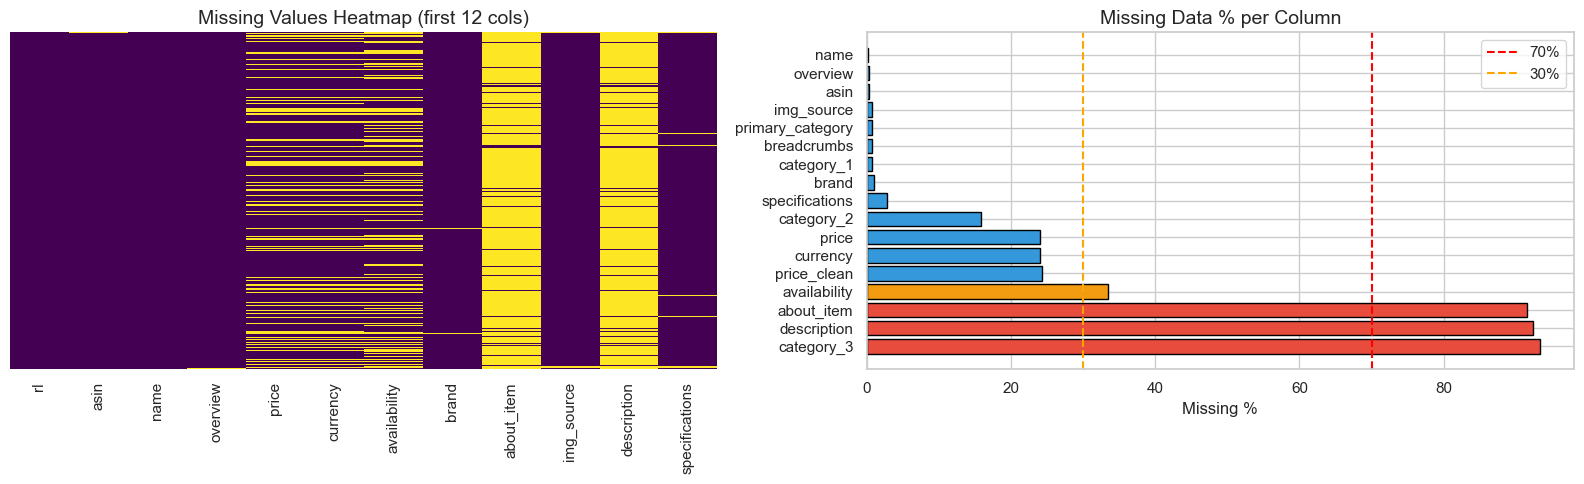

                  Missing Count  Missing Pct
category_3                 1351         93.4
description                1337         92.4
about_item                 1326         91.6
availability                484         33.4
price_clean                 352         24.3
currency                    349         24.1
price                       348         24.0
category_2                  230         15.9
specifications               40          2.8
brand                        14          1.0
category_1                   12          0.8
breadcrumbs                  12          0.8
primary_category             11          0.8
img_source                   11          0.8
asin                          6          0.4
overview                      5          0.3
name                          3          0.2


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Resumen de valores faltantes
missing = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing Pct': (df.isnull().sum() / len(df) * 100).round(1)
}).sort_values('Missing Pct', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Heatmap (hasta 12 columnas o las disponibles)
n_cols = min(12, len(df.columns))

sns.heatmap(
    df[df.columns[:n_cols]].isnull(),
    cbar=False,
    yticklabels=False,
    cmap='viridis',
    ax=axes[0]
)

axes[0].set_title(f'Missing Values Heatmap (first {n_cols} cols)')

# Columnas con valores faltantes
mv = missing[missing['Missing Pct'] > 0]

if not mv.empty:
    colors_mv = [
        '#e74c3c' if v > 70 else '#f39c12' if v > 30 else '#3498db'
        for v in mv['Missing Pct']
    ]

    axes[1].barh(
        mv.index,
        mv['Missing Pct'],
        color=colors_mv,
        edgecolor='black'
    )

    axes[1].axvline(70, color='red', linestyle='--', label='70%')
    axes[1].axvline(30, color='orange', linestyle='--', label='30%')
    axes[1].legend()
else:
    axes[1].text(
        0.5, 0.5,
        'No missing values found',
        ha='center',
        va='center',
        fontsize=12
    )

axes[1].set_xlabel('Missing %')
axes[1].set_title('Missing Data % per Column')

plt.tight_layout()
plt.show()

# Imprimir resumen
missing_rows = missing[missing['Missing Count'] > 0]

if not missing_rows.empty:
    print(missing_rows.to_string())
else:
    print("No missing values found.")

### 4. Ingeniería de Características ()

<div style="background:#f0fff0; padding:12px; border-left:4px solid #27ae60; border-radius:5px; color: #0066cc;">
<b> Ejemplo Cotidiano:</b> un agente inmobiliario no solo utiliza los metrso cuadrados brutos, si no tambien consi9dera la ubicacion, la natiguedad y el estado ,
nosotros hacemos lo mismo: extraemos informacion mas valiosa del textor sin procesar y las categorias. 
</div>


In [7]:
# ============================================================
# SECTION 3 — Feature Engineering
# ============================================================

# ── Category flags ───────────────────────────────────────────
df['is_book']    = (df['primary_category'] == 'Books').astype(int) # Esta instruccion imprime laas columnas df enlistadas en este caso Name,
#isbook que hace referecnia al nombre del producto y un boleano si es libro o no.
df['is_kindle']  = (df['primary_category'] == 'Kindle Store').astype(int)
df['is_sports']  = (df['primary_category'].str.contains('Sport', na=False)).astype(int)

# ── Sub-category flags ───────────────────────────────────────
df['is_fiction']    = df['category_1'].fillna('').str.contains('Fiction|Adventure|Crime|Romance|Sci-Fi', case=False).astype(int)
df['is_nonfiction'] = df['category_1'].fillna('').str.contains('History|Politics|Business|Science|Education', case=False).astype(int)
df['is_tech']       = df['category_1'].fillna('').str.contains('Computer|Programming|Technology', case=False).astype(int)
df['is_cycling']    = df['category_1'].fillna('').str.contains('Cycling', case=False).astype(int)

# ── Availability flags ───────────────────────────────────────
df['is_instock']     = (df['avail_clean'] == 'In Stock').astype(int)
df['is_unavailable'] = (df['avail_clean'] == 'Unavailable').astype(int)
df['is_lowstock']    = (df['avail_clean'] == 'Low Stock').astype(int)

# ── Price features ───────────────────────────────────────────
df['log_price'] = np.log1p(df['price_clean'])

def price_tier(p):
    if pd.isna(p):  return 'Unknown'
    if p < 300:     return '1_budget'
    if p < 800:     return '2_low'
    if p < 1500:    return '3_mid'
    if p < 3000:    return '4_premium'
    return '5_luxury'

df['price_tier'] = df['price_clean'].apply(price_tier)

# ── Label encode primary category ───────────────────────────
le_cat = LabelEncoder()
df['primary_cat_enc'] = le_cat.fit_transform(df['primary_category'].fillna('Unknown'))

le_cat1 = LabelEncoder()
df['cat1_enc'] = le_cat1.fit_transform(df['category_1'].fillna('Unknown'))

le_avail = LabelEncoder()
df['avail_enc'] = le_avail.fit_transform(df['avail_clean'])

print(f'✅ Total de características generadas: {len(df.columns)}')
print('\nDistribución de los rangos de precios:')
print(df['price_tier'].value_counts().sort_index().to_string())
df[['name','price_clean','price_tier','primary_category','is_book','is_instock']].head(6)



✅ Total de características generadas: 39

Distribución de los rangos de precios:
price_tier
1_budget     106
2_low        285
3_mid        319
4_premium    259
5_luxury     126
Unknown      352


,name,price_clean,price_tier,primary_category,is_book,is_instock
0,[],NaN,Unknown,NaN,0,0
1,The Blazing Horizon The True Story of Pawnee B...,2399.0,4_premium,Books,1,0
2,Fast and easy lunch box: A collection of 15eas...,NaN,Unknown,Kindle Store,0,0
3,European Foreign Policy Scorecard 2014,NaN,Unknown,Kindle Store,0,0
4,The 13th Hour: Chaos (Volume 2) (The Nick Quin...,1849.0,4_premium,Books,1,0
5,Valerius Maximus' Memorable Deeds and Sayings ...,NaN,Unknown,Books,1,0


## 5. Analisis Universal 📊 <a id='s4'></a>

<div style="background:#f0f8ff; padding:12px; border-left:4px solid #3498db; border-radius:5px; color: #0066cc;">
<b>Key question:</b> What does the price distribution look like? Are there outliers? Is the data skewed?
</div>

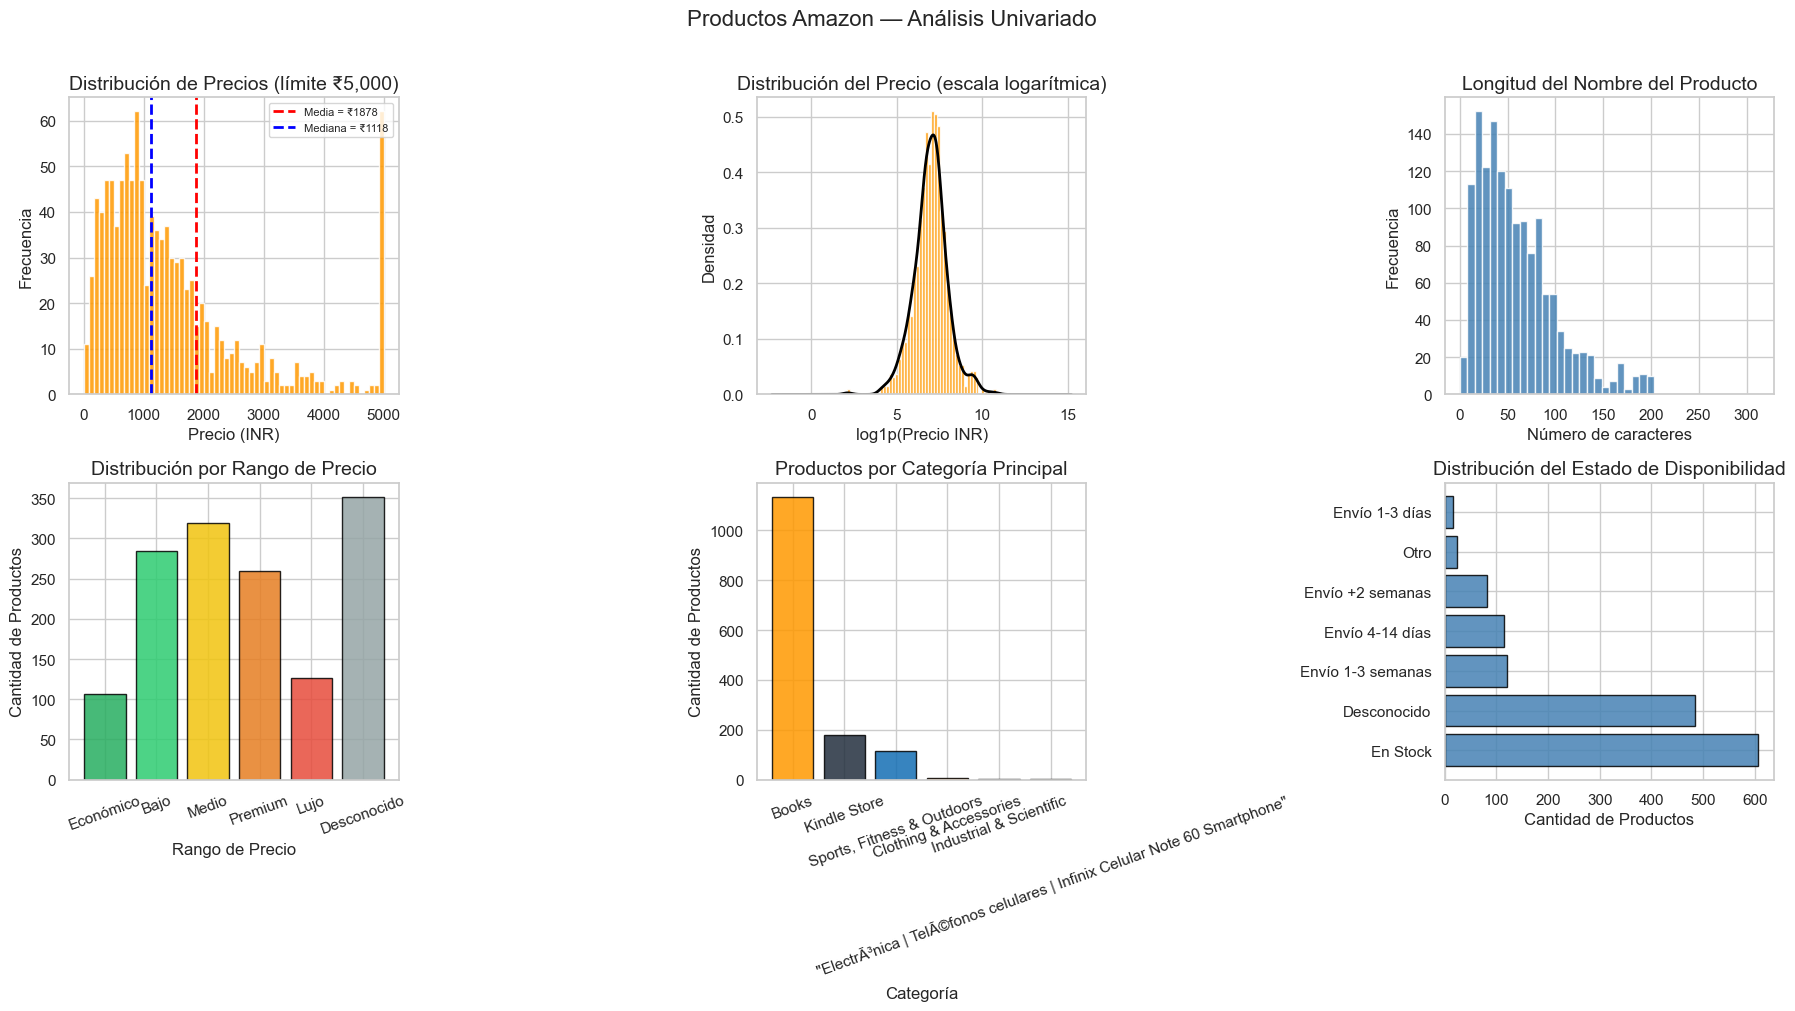

Prueba Shapiro-Wilk (precio logarítmico, n=500)
Estadístico = 0.9796, p-valor = 0.000002
La distribución del precio sigue sin ser normal después de la transformación logarítmica.

Estadísticas descriptivas del precio (INR):
count     1088.00
mean      1877.87
std       3338.95
min          7.00
25%        608.50
50%       1117.50
75%       1850.00
max      50555.00


In [8]:
# ============================================================
# SECTION 4 — Análisis Univariado
# ============================================================
import matplotlib.pyplot as plt
from scipy.stats import shapiro

df_priced = df[df['price_clean'].notna() & (df['price_clean'] > 0)].copy()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Distribución de precios
axes[0,0].hist(df_priced['price_clean'].clip(upper=5000), bins=60,
               color='#FF9900', edgecolor='white', alpha=0.85)

axes[0,0].axvline(
    df_priced['price_clean'].mean(),
    color='red', linestyle='--', lw=2,
    label=f'Media = ₹{df_priced["price_clean"].mean():.0f}'
)

axes[0,0].axvline(
    df_priced['price_clean'].median(),
    color='blue', linestyle='--', lw=2,
    label=f'Mediana = ₹{df_priced["price_clean"].median():.0f}'
)

axes[0,0].set_title('Distribución de Precios (límite ₹5,000)')
axes[0,0].set_xlabel('Precio (INR)')
axes[0,0].set_ylabel('Frecuencia')
axes[0,0].legend(fontsize=8)

# Distribución logarítmica del precio
axes[0,1].hist(
    df_priced['log_price'],
    bins=50,
    color='#FF9900',
    edgecolor='white',
    alpha=0.85,
    density=True
)

df_priced['log_price'].plot.kde(ax=axes[0,1], color='black', lw=2)

axes[0,1].set_title('Distribución del Precio (escala logarítmica)')
axes[0,1].set_xlabel('log1p(Precio INR)')
axes[0,1].set_ylabel('Densidad')

# Longitud del nombre del producto
axes[0,2].hist(
    df['name_length'],
    bins=40,
    color='steelblue',
    edgecolor='white',
    alpha=0.85
)

axes[0,2].set_title('Longitud del Nombre del Producto')
axes[0,2].set_xlabel('Número de caracteres')
axes[0,2].set_ylabel('Frecuencia')

# Rangos de precio
tier_counts = df['price_tier'].value_counts().sort_index()

# Traducción de categorías de precio
tier_labels = {
    '1_budget': 'Económico',
    '2_low': 'Bajo',
    '3_mid': 'Medio',
    '4_premium': 'Premium',
    '5_luxury': 'Lujo',
    'Unknown': 'Desconocido'
}

tier_counts.index = [tier_labels.get(x, x) for x in tier_counts.index]

tier_colors = ['#27ae60','#2ecc71','#f1c40f','#e67e22','#e74c3c','#95a5a6']

axes[1,0].bar(
    tier_counts.index,
    tier_counts.values,
    color=tier_colors[:len(tier_counts)],
    edgecolor='black',
    alpha=0.85
)

axes[1,0].set_title('Distribución por Rango de Precio')
axes[1,0].set_xlabel('Rango de Precio')
axes[1,0].set_ylabel('Cantidad de Productos')
axes[1,0].tick_params(axis='x', rotation=20)

# Categoría principal
cat_counts = df['primary_category'].value_counts()

axes[1,1].bar(
    cat_counts.index,
    cat_counts.values,
    color=['#FF9900','#232F3E','#146EB4','#E47911','#999'],
    edgecolor='black',
    alpha=0.85
)

axes[1,1].set_title('Productos por Categoría Principal')
axes[1,1].set_xlabel('Categoría')
axes[1,1].set_ylabel('Cantidad de Productos')
axes[1,1].tick_params(axis='x', rotation=20)

# Disponibilidad
avail_counts = df['avail_clean'].value_counts()

# Traducción de estados de disponibilidad
avail_translation = {
    'In Stock': 'En Stock',
    'Unknown': 'Desconocido',
    'Ships 1-3 weeks': 'Envío 1-3 semanas',
    'Ships 2+ weeks': 'Envío +2 semanas',
    'Ships 4-14 days': 'Envío 4-14 días',
    'Ships 1-3 days': 'Envío 1-3 días',
    'Other': 'Otro'
}

avail_counts.index = [
    avail_translation.get(x, x)
    for x in avail_counts.index
]

axes[1,2].barh(
    avail_counts.index,
    avail_counts.values,
    color='steelblue',
    edgecolor='black',
    alpha=0.85
)

axes[1,2].set_title('Distribución del Estado de Disponibilidad')
axes[1,2].set_xlabel('Cantidad de Productos')

plt.suptitle(
    'Productos Amazon — Análisis Univariado',
    fontsize=16,
    y=1.01
)

plt.tight_layout()
plt.show()

# --------------------------------------------------
# Prueba de normalidad
# --------------------------------------------------
stat, p = shapiro(
    df_priced['log_price'].sample(
        min(500, len(df_priced)),
        random_state=42
    )
)

print(f'Prueba Shapiro-Wilk (precio logarítmico, n=500)')
print(f'Estadístico = {stat:.4f}, p-valor = {p:.6f}')

if p > 0.05:
    print('La distribución del precio puede considerarse normal después de la transformación logarítmica.')
else:
    print('La distribución del precio sigue sin ser normal después de la transformación logarítmica.')

print('\nEstadísticas descriptivas del precio (INR):')
print(df_priced['price_clean'].describe().round(2).to_string())


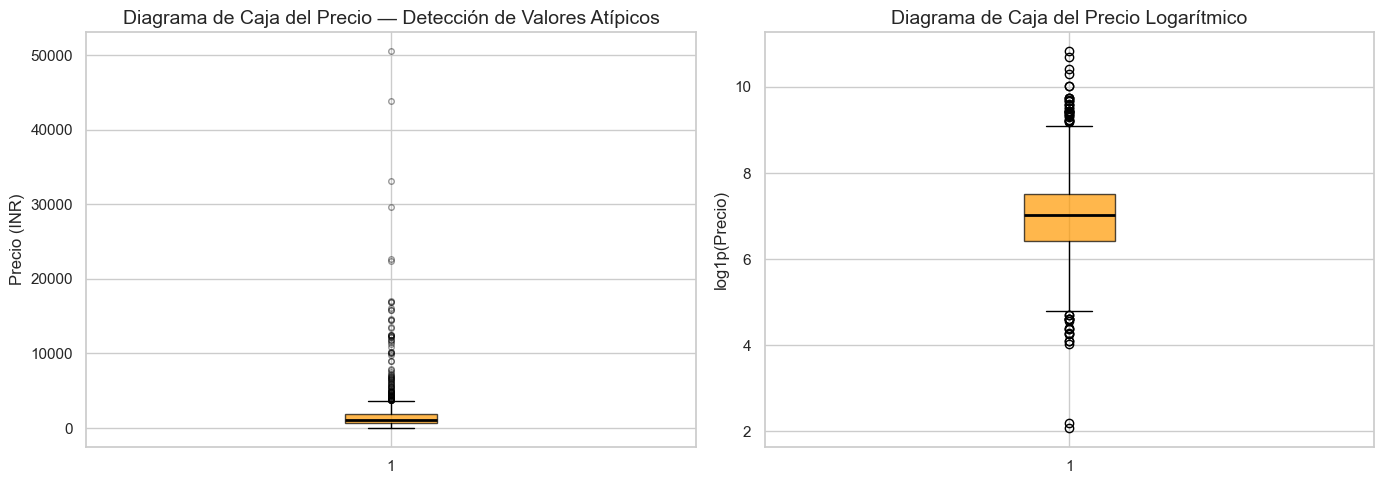

ANÁLISIS DE VALORES ATÍPICOS MEDIANTE IQR
Valores atípicos detectados (método IQR): 93 (8.5%)
Rango de precios sin valores atípicos: ₹-1254 – ₹3712

LOS 10 PRODUCTOS MÁS CAROS
                                                                                                                                        name  price_clean           primary_category
                                            Sprache und Literatur (Literatur der julisch-claudischen und der flavischen Zeit [Schluss]): 032     50555.00                      Books
                                                         Data Mining Algorithms in C++: Data Patterns and Algorithms for Modern Applications     43936.00                      Books
                                                                                Birnbaum's Walt Disney World for Kids 2008 (Birnbaum Guides)     33180.00                      Books
                                                                            Professional Short Films

In [9]:
# ============================================================
# Análisis de Valores Atípicos (Outliers) — Boxplot e IQR
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot de precios originales
axes[0].boxplot(
    df_priced['price_clean'],
    patch_artist=True,
    boxprops=dict(facecolor='#FF9900', alpha=0.7),
    medianprops=dict(color='black', lw=2),
    flierprops=dict(marker='o', markersize=4, alpha=0.4, color='red')
)

axes[0].set_title('Diagrama de Caja del Precio — Detección de Valores Atípicos')
axes[0].set_ylabel('Precio (INR)')

# Boxplot de precios transformados con logaritmo
axes[1].boxplot(
    df_priced['log_price'],
    patch_artist=True,
    boxprops=dict(facecolor='#FF9900', alpha=0.7),
    medianprops=dict(color='black', lw=2)
)

axes[1].set_title('Diagrama de Caja del Precio Logarítmico')
axes[1].set_ylabel('log1p(Precio)')

plt.tight_layout()
plt.show()

# ============================================================
# Método IQR para detección de valores atípicos
# ============================================================

Q1, Q3 = df_priced['price_clean'].quantile([0.25, 0.75])
IQR = Q3 - Q1

outliers = df_priced[
    (df_priced['price_clean'] < Q1 - 1.5 * IQR) |
    (df_priced['price_clean'] > Q3 + 1.5 * IQR)
]

print("=" * 60)
print("ANÁLISIS DE VALORES ATÍPICOS MEDIANTE IQR")
print("=" * 60)

print(
    f"Valores atípicos detectados (método IQR): "
    f"{len(outliers)} ({len(outliers)/len(df_priced)*100:.1f}%)"
)

print(
    f"Rango de precios sin valores atípicos: "
    f"₹{Q1 - 1.5*IQR:.0f} – ₹{Q3 + 1.5*IQR:.0f}"
)

print("\n" + "=" * 60)
print("LOS 10 PRODUCTOS MÁS CAROS")
print("=" * 60)

print(
    df_priced
    .nlargest(10, 'price_clean')
    [['name', 'price_clean', 'primary_category']]
    .to_string(index=False)
)

## 6. Análisis de categorías 🗂️ <a id='s5'></a>

<div style="background:#fff8e1; padding:12px; border-left:4px solid #FF9900; border-radius:5px; color: #0066cc;">
<b>Pregunta clave:</b> ¿Qué categorías tienen los precios más altos? ¿Qué subcategorías dominan? ¿Dónde está el mayor valor?
</div>

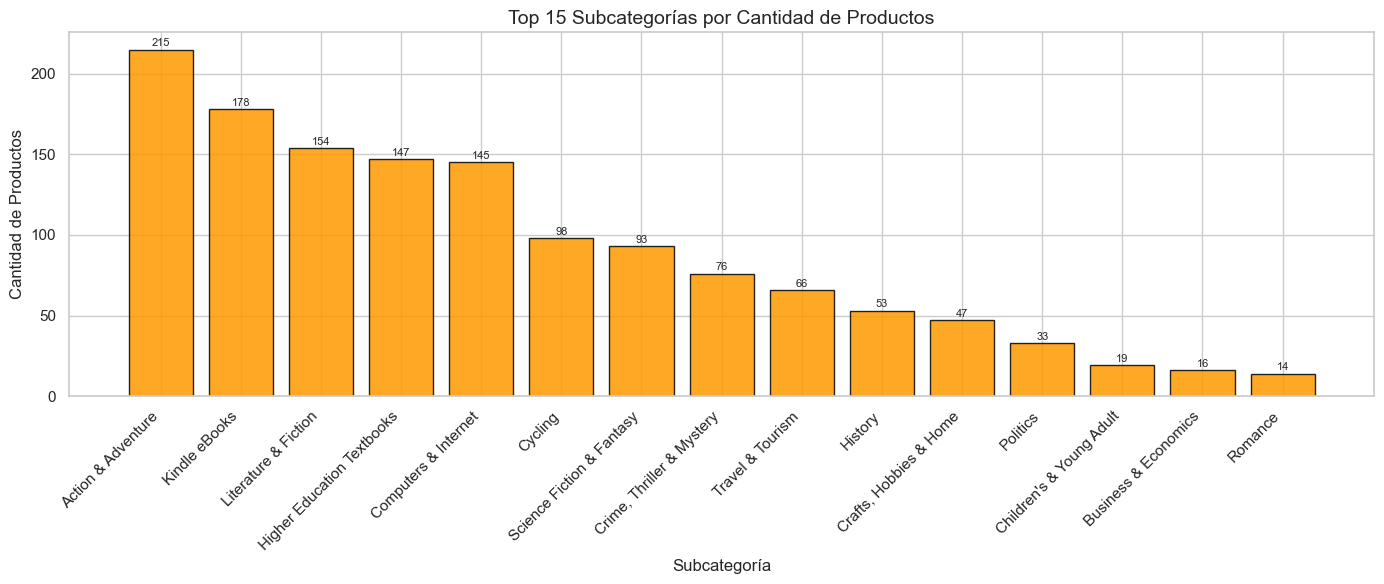

In [10]:
# ============================================================
# SECTION 5 — Análisis de Categorías
# ============================================================

# Top 15 subcategorías con más productos
top15_cat1 = df['category_1'].value_counts().head(15)

plt.figure(figsize=(14, 6))

bars = plt.bar(
    top15_cat1.index,
    top15_cat1.values,
    color='#FF9900',
    edgecolor='black',
    alpha=0.85
)

# Etiquetas de cantidad sobre cada barra
for bar, val in zip(bars, top15_cat1.values):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 2,
        str(val),
        ha='center',
        fontsize=8
    )

plt.title('Top 15 Subcategorías por Cantidad de Productos')
plt.xlabel('Subcategoría')
plt.ylabel('Cantidad de Productos')

plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

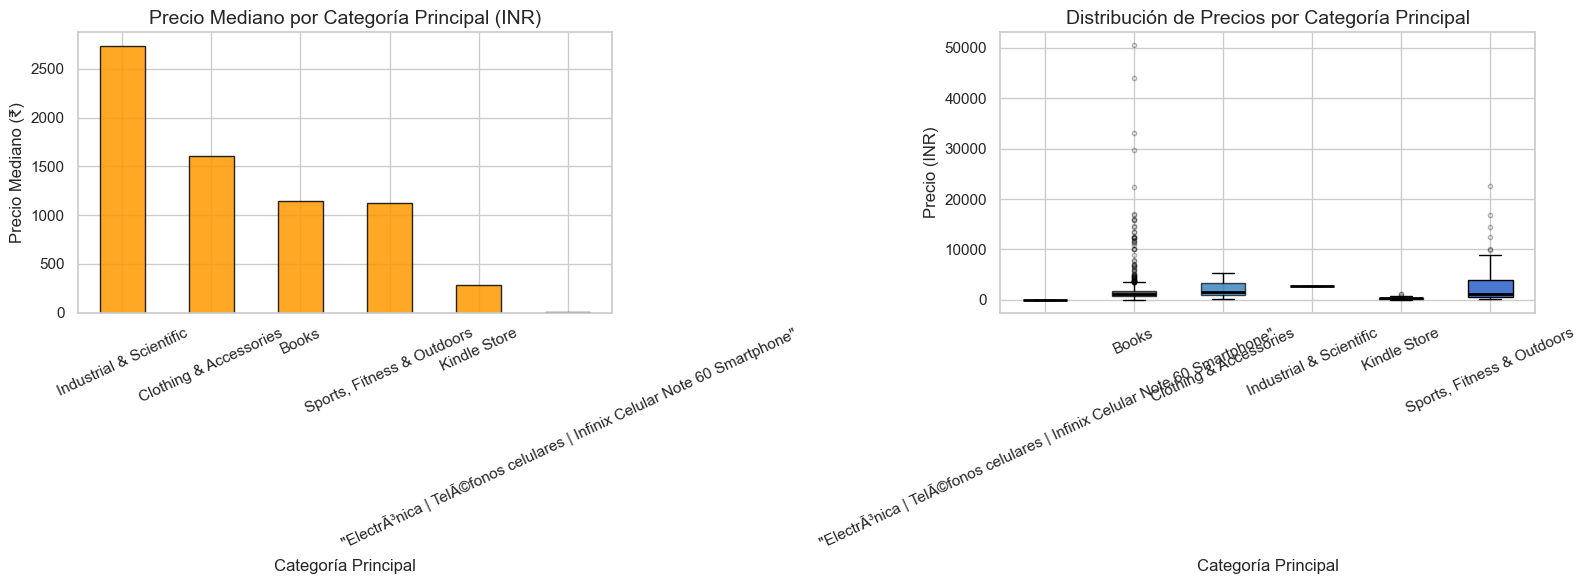


ESTADÍSTICAS DE PRECIOS POR CATEGORÍA PRINCIPAL
                                                                             Precio Promedio  Precio Mediano  Cantidad de Productos
primary_category                                                                                                                   
 "ElectrÃ³nica | TelÃ©fonos celulares | Infinix Celular Note 60 Smartphone"              8.0             8.0                      1
Books                                                                                 1825.8          1143.5                    954
Clothing & Accessories                                                                2249.2          1606.5                      6
Industrial & Scientific                                                               2738.0          2738.0                      1
Kindle Store                                                                           350.0           281.4                     30
Sports, Fitness & Outdoors 

In [11]:
# ============================================================
# Precio por Categoría Principal
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --------------------------------------------------
# Estadísticas por categoría
# --------------------------------------------------

cat_price = (
    df_priced
    .groupby('primary_category')['price_clean']
    .agg(['mean', 'median', 'count'])
    .round(1)
)

# --------------------------------------------------
# Gráfico de barras (Precio mediano)
# --------------------------------------------------

cat_price['median'].sort_values(ascending=False).plot.bar(
    ax=axes[0],
    color='#FF9900',
    edgecolor='black',
    alpha=0.85
)

axes[0].set_title('Precio Mediano por Categoría Principal (INR)')
axes[0].set_xlabel('Categoría Principal')
axes[0].set_ylabel('Precio Mediano (₹)')
axes[0].tick_params(axis='x', rotation=25)

# --------------------------------------------------
# Boxplot de distribución de precios
# --------------------------------------------------

cat_groups = [
    df_priced[
        df_priced['primary_category'] == categoria
    ]['price_clean'].dropna()
    for categoria in cat_price.index
]

bp = axes[1].boxplot(
    cat_groups,
    tick_labels=cat_price.index,  # ← evita el warning
    patch_artist=True,
    medianprops=dict(
        color='black',
        lw=2
    ),
    flierprops=dict(
        marker='o',
        markersize=3,
        alpha=0.3
    )
)

colors_cat = [
    '#FF9900',
    '#232F3E',
    '#146EB4',
    '#E47911',
    '#999999'
]

for patch, color in zip(bp['boxes'], colors_cat):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

axes[1].set_title('Distribución de Precios por Categoría Principal')
axes[1].set_xlabel('Categoría Principal')
axes[1].set_ylabel('Precio (INR)')
axes[1].tick_params(axis='x', rotation=25)

plt.tight_layout()
plt.show()

# ============================================================
# Tabla de estadísticas
# ============================================================

cat_price_es = cat_price.rename(columns={
    'mean': 'Precio Promedio',
    'median': 'Precio Mediano',
    'count': 'Cantidad de Productos'
})

print("\n" + "="*70)
print("ESTADÍSTICAS DE PRECIOS POR CATEGORÍA PRINCIPAL")
print("="*70)

print(cat_price_es.to_string())

# ============================================================
# Resumen adicional
# ============================================================

categoria_mas_cara = cat_price['median'].idxmax()
precio_mas_alto = cat_price['median'].max()

categoria_mas_barata = cat_price['median'].idxmin()
precio_mas_bajo = cat_price['median'].min()

print("\n" + "="*70)
print("RESUMEN")
print("="*70)

print(
    f"Categoría con mayor precio mediano: "
    f"{categoria_mas_cara} (₹{precio_mas_alto:,.0f})"
)

print(
    f"Categoría con menor precio mediano: "
    f"{categoria_mas_barata} (₹{precio_mas_bajo:,.0f})"
)

print(
    f"Número total de categorías analizadas: "
    f"{len(cat_price)}"
)

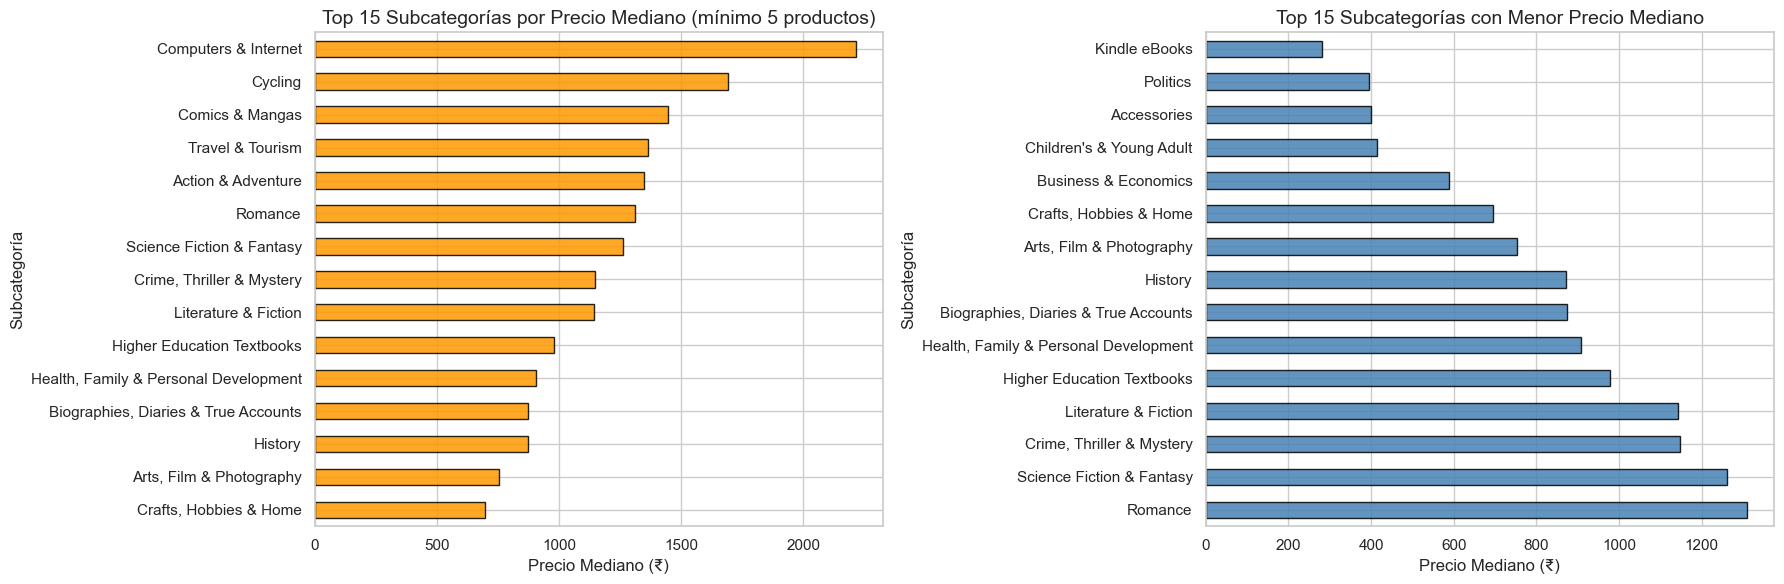

In [12]:
# ============================================================
# Top 15 Subcategorías por Precio Mediano
# ============================================================

top_cat1_price = (
    df_priced
    .groupby('category_1')['price_clean']
    .agg(['median', 'count'])
    .query('count >= 5')
    .sort_values('median', ascending=False)
    .head(15)
)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# --------------------------------------------------
# 15 subcategorías más caras
# --------------------------------------------------

top_cat1_price['median'].sort_values().plot.barh(
    ax=axes[0],
    color='#FF9900',
    edgecolor='black',
    alpha=0.85
)

axes[0].set_title(
    'Top 15 Subcategorías por Precio Mediano (mínimo 5 productos)'
)
axes[0].set_xlabel('Precio Mediano (₹)')
axes[0].set_ylabel('Subcategoría')

# --------------------------------------------------
# 15 subcategorías más económicas
# --------------------------------------------------

bottom_cat1 = (
    df_priced
    .groupby('category_1')['price_clean']
    .agg(['median', 'count'])
    .query('count >= 5')
    .sort_values('median')
    .head(15)
)

bottom_cat1['median'].sort_values(ascending=False).plot.barh(
    ax=axes[1],
    color='steelblue',
    edgecolor='black',
    alpha=0.85
)

axes[1].set_title(
    'Top 15 Subcategorías con Menor Precio Mediano'
)
axes[1].set_xlabel('Precio Mediano (₹)')
axes[1].set_ylabel('Subcategoría')

plt.tight_layout()
plt.show()

## 7. Availability Analysis 📦 <a id='s6'></a>

<div style="background:#f0fff0; padding:12px; border-left:4px solid #27ae60; border-radius:5px; color: #0066cc;">
<b>Pregunta clave:</b> ¿El estado de disponibilidad afecta el precio? ¿Es más probable que los productos premium se agoten?
</div>

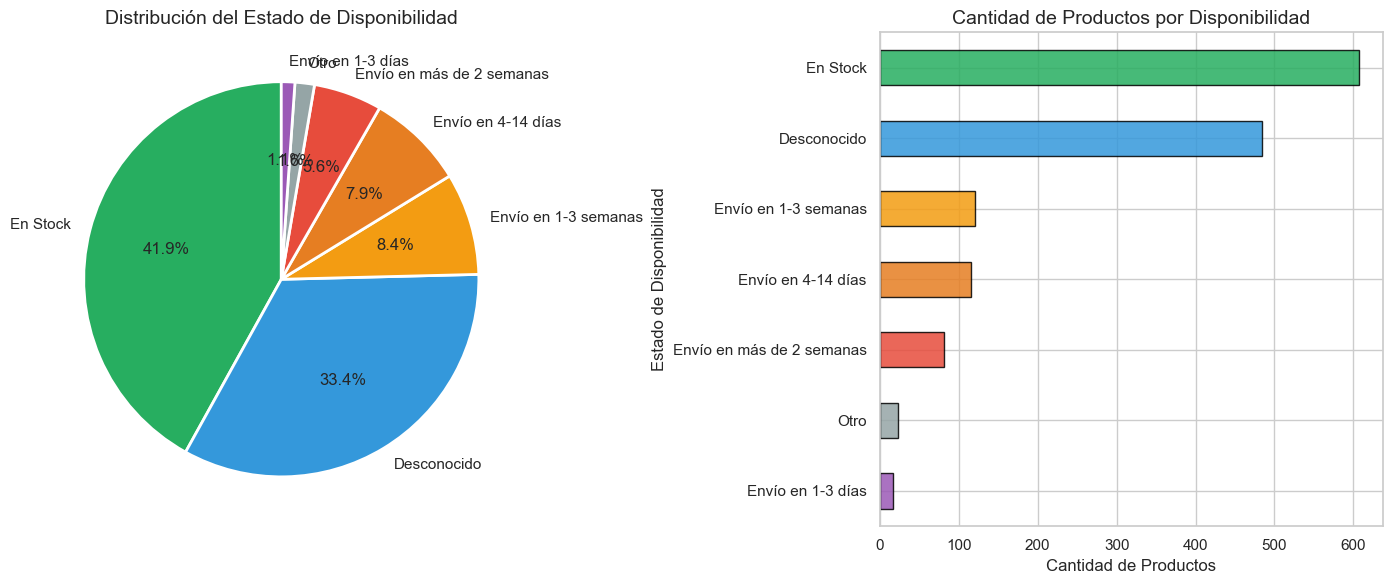

In [13]:
# ============================================================
# SECTION 6 — Análisis de Disponibilidad
# ============================================================

# Traducir estados de disponibilidad
avail_translation = {
    'In Stock': 'En Stock',
    'Unknown': 'Desconocido',
    'Ships 1-3 days': 'Envío en 1-3 días',
    'Ships 4-14 days': 'Envío en 4-14 días',
    'Ships 1-3 weeks': 'Envío en 1-3 semanas',
    'Ships 2+ weeks': 'Envío en más de 2 semanas',
    'Other': 'Otro'
}

avail_counts = df['avail_clean'].value_counts()

# Aplicar traducción a las etiquetas
avail_counts.index = [
    avail_translation.get(x, x)
    for x in avail_counts.index
]

avail_colors = [
    '#27ae60',
    '#3498db',
    '#f39c12',
    '#e67e22',
    '#e74c3c',
    '#95a5a6',
    '#9b59b6',
    '#1abc9c'
]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --------------------------------------------------
# Gráfico circular
# --------------------------------------------------

axes[0].pie(
    avail_counts.values,
    labels=avail_counts.index,
    colors=avail_colors[:len(avail_counts)],
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops=dict(
        edgecolor='white',
        linewidth=2
    )
)

axes[0].set_title('Distribución del Estado de Disponibilidad')

# --------------------------------------------------
# Gráfico de barras horizontal
# --------------------------------------------------

avail_counts.sort_values().plot.barh(
    ax=axes[1],
    color=avail_colors[:len(avail_counts)][::-1],
    edgecolor='black',
    alpha=0.85
)

axes[1].set_title('Cantidad de Productos por Disponibilidad')
axes[1].set_xlabel('Cantidad de Productos')
axes[1].set_ylabel('Estado de Disponibilidad')

plt.tight_layout()
plt.show()

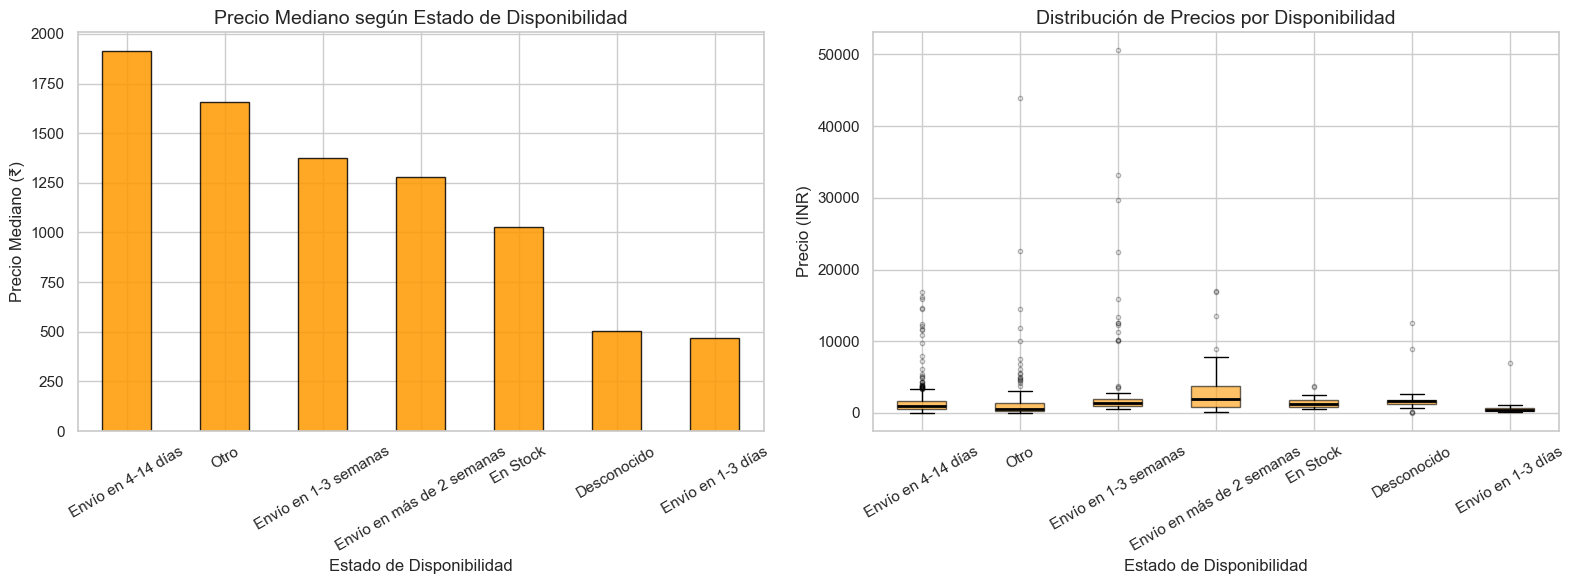


ESTADÍSTICAS DE PRECIO SEGÚN DISPONIBILIDAD
                           Precio Mediano  Precio Promedio  Cantidad de Productos
Envío en 4-14 días                 1912.3           2874.6                    115
Otro                               1659.0           2241.1                     22
Envío en 1-3 semanas               1377.0           3231.6                    121
Envío en más de 2 semanas          1279.0           1398.4                     81
En Stock                           1030.0           1490.5                    599
Desconocido                         502.0           1881.5                    134
Envío en 1-3 días                   469.0            874.9                     16


In [14]:
# ============================================================
# Precio según Estado de Disponibilidad
# ============================================================

# Traducción de estados de disponibilidad
avail_translation = {
    'In Stock': 'En Stock',
    'Unknown': 'Desconocido',
    'Ships 1-3 days': 'Envío en 1-3 días',
    'Ships 4-14 days': 'Envío en 4-14 días',
    'Ships 1-3 weeks': 'Envío en 1-3 semanas',
    'Ships 2+ weeks': 'Envío en más de 2 semanas',
    'Other': 'Otro'
}

avail_price = (
    df_priced
    .groupby('avail_clean')['price_clean']
    .agg(['median', 'mean', 'count'])
    .round(1)
)

avail_price = (
    avail_price[avail_price['count'] >= 5]
    .sort_values('median', ascending=False)
)

# Traducir índices
avail_price.index = [
    avail_translation.get(x, x)
    for x in avail_price.index
]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --------------------------------------------------
# Gráfico de barras
# --------------------------------------------------

avail_price['median'].plot.bar(
    ax=axes[0],
    color='#FF9900',
    edgecolor='black',
    alpha=0.85
)

axes[0].set_title('Precio Mediano según Estado de Disponibilidad')
axes[0].set_xlabel('Estado de Disponibilidad')
axes[0].set_ylabel('Precio Mediano (₹)')
axes[0].tick_params(axis='x', rotation=30)

# --------------------------------------------------
# Boxplot
# --------------------------------------------------

avail_groups = [
    df_priced[
        df_priced['avail_clean'] == estado_original
    ]['price_clean'].dropna()
    for estado_original in (
        df_priced['avail_clean']
        .value_counts()
        .index
        .intersection(
            [k for k, v in avail_translation.items()
             if v in avail_price.index]
        )
    )
]

bp = axes[1].boxplot(
    avail_groups,
    tick_labels=avail_price.index,
    patch_artist=True,
    medianprops=dict(
        color='black',
        lw=2
    ),
    flierprops=dict(
        marker='o',
        markersize=3,
        alpha=0.3
    )
)

for patch in bp['boxes']:
    patch.set_facecolor('#FF9900')
    patch.set_alpha(0.6)

axes[1].set_title('Distribución de Precios por Disponibilidad')
axes[1].set_xlabel('Estado de Disponibilidad')
axes[1].set_ylabel('Precio (INR)')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

# ============================================================
# Tabla de resultados
# ============================================================

avail_price_es = avail_price.rename(columns={
    'median': 'Precio Mediano',
    'mean': 'Precio Promedio',
    'count': 'Cantidad de Productos'
})

print("\n" + "="*70)
print("ESTADÍSTICAS DE PRECIO SEGÚN DISPONIBILIDAD")
print("="*70)

print(avail_price_es.to_string())


## 8. Correlation & Bivariate Analysis 🔗 <a id='s7'></a>

<div style="background:#f0f8ff; padding:12px; border-left:4px solid #3498db; border-radius:5px; color: #0066cc;">
<b> Pregunta clave: </b> ¿Qué características están más correlacionadas con el precio? ¿La longitud del nombre predice el precio?
</div>


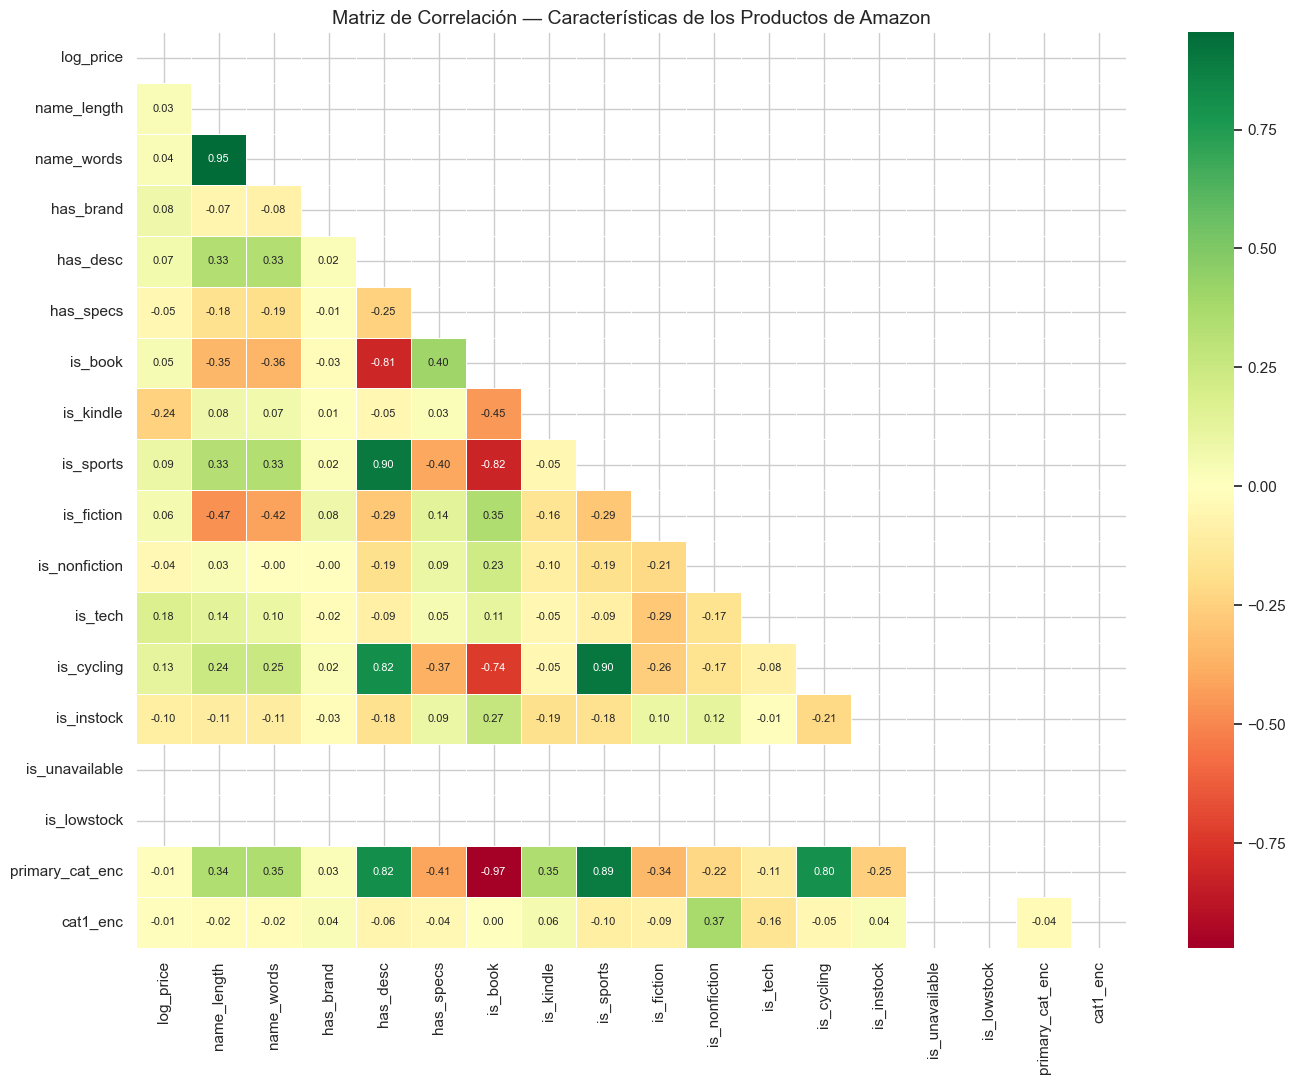


CORRELACIONES MÁS IMPORTANTES CON EL PRECIO
is_tech            0.176046
is_cycling         0.126940
is_sports          0.092698
has_brand          0.082140
has_desc           0.065556
is_fiction         0.058535
is_book            0.050968
name_words         0.035443
name_length        0.030477
primary_cat_enc   -0.010385
cat1_enc          -0.012391
is_nonfiction     -0.039664
has_specs         -0.046761
is_instock        -0.104767
is_kindle         -0.242271
is_unavailable          NaN
is_lowstock             NaN


In [15]:
# ============================================================
# SECTION 7 — Análisis de Correlación
# ============================================================

corr_cols = [
    'log_price',
    'name_length',
    'name_words',
    'has_brand',
    'has_desc',
    'has_specs',
    'is_book',
    'is_kindle',
    'is_sports',
    'is_fiction',
    'is_nonfiction',
    'is_tech',
    'is_cycling',
    'is_instock',
    'is_unavailable',
    'is_lowstock',
    'primary_cat_enc',
    'cat1_enc'
]

corr = df_priced[corr_cols].corr()

mask = np.triu(
    np.ones_like(corr, dtype=bool)
)

plt.figure(figsize=(14, 11))

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    linewidths=0.4,
    annot_kws={'size': 8}
)

plt.title(
    'Matriz de Correlación — Características de los Productos de Amazon',
    fontsize=14
)

plt.tight_layout()
plt.show()

# ============================================================
# Correlaciones con el precio
# ============================================================

print("\n" + "="*70)
print("CORRELACIONES MÁS IMPORTANTES CON EL PRECIO")
print("="*70)

corr_log_price = (
    corr['log_price']
    .drop('log_price')
    .sort_values(ascending=False)
)

print(corr_log_price.to_string())

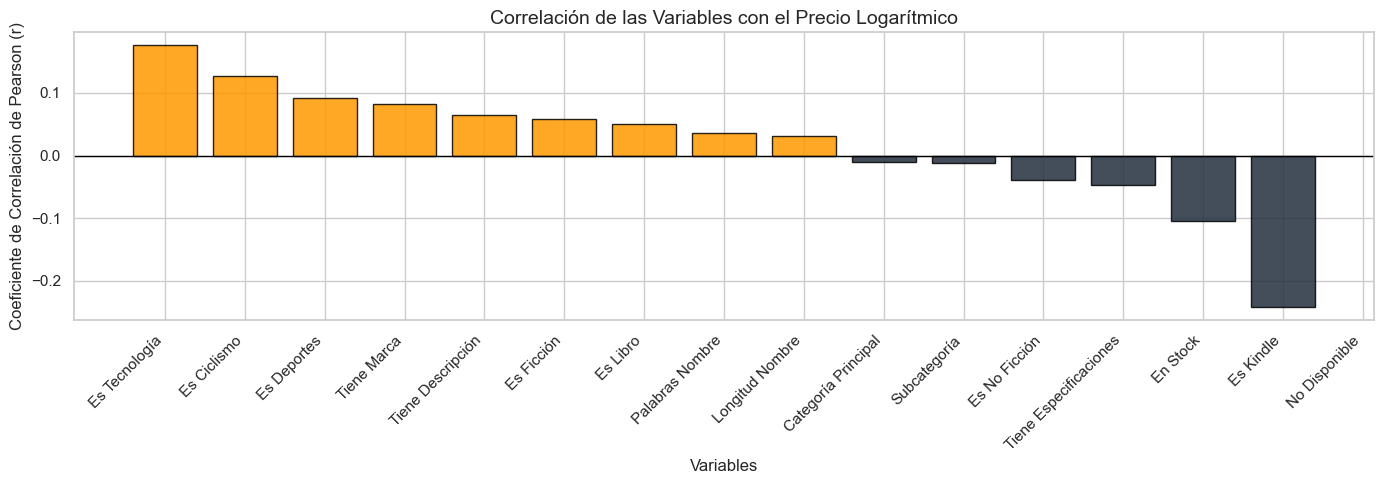

In [16]:
# ============================================================
# Gráfico de Correlación de Variables con el Precio
# ============================================================

# Correlaciones con el precio logarítmico
feat_corr = (
    corr['log_price']
    .drop('log_price')
    .sort_values(ascending=False)
)

# Traducción de nombres de variables
corr_labels = {
    'name_length': 'Longitud Nombre',
    'name_words': 'Palabras Nombre',
    'has_brand': 'Tiene Marca',
    'has_desc': 'Tiene Descripción',
    'has_specs': 'Tiene Especificaciones',
    'is_book': 'Es Libro',
    'is_kindle': 'Es Kindle',
    'is_sports': 'Es Deportes',
    'is_fiction': 'Es Ficción',
    'is_nonfiction': 'Es No Ficción',
    'is_tech': 'Es Tecnología',
    'is_cycling': 'Es Ciclismo',
    'is_instock': 'En Stock',
    'is_unavailable': 'No Disponible',
    'is_lowstock': 'Stock Bajo',
    'primary_cat_enc': 'Categoría Principal',
    'cat1_enc': 'Subcategoría'
}

feat_corr.index = [
    corr_labels.get(x, x)
    for x in feat_corr.index
]

# Colores según el signo de la correlación
colors_fc = [
    '#FF9900' if valor > 0 else '#232F3E'
    for valor in feat_corr.values
]

plt.figure(figsize=(14, 5))

plt.bar(
    feat_corr.index,
    feat_corr.values,
    color=colors_fc,
    edgecolor='black',
    alpha=0.85
)

plt.axhline(
    0,
    color='black',
    lw=1
)

plt.title(
    'Correlación de las Variables con el Precio Logarítmico'
)

plt.ylabel('Coeficiente de Correlación de Pearson (r)')
plt.xlabel('Variables')

plt.xticks(
    rotation=45,
    ha='right'
)

plt.tight_layout()
plt.show()

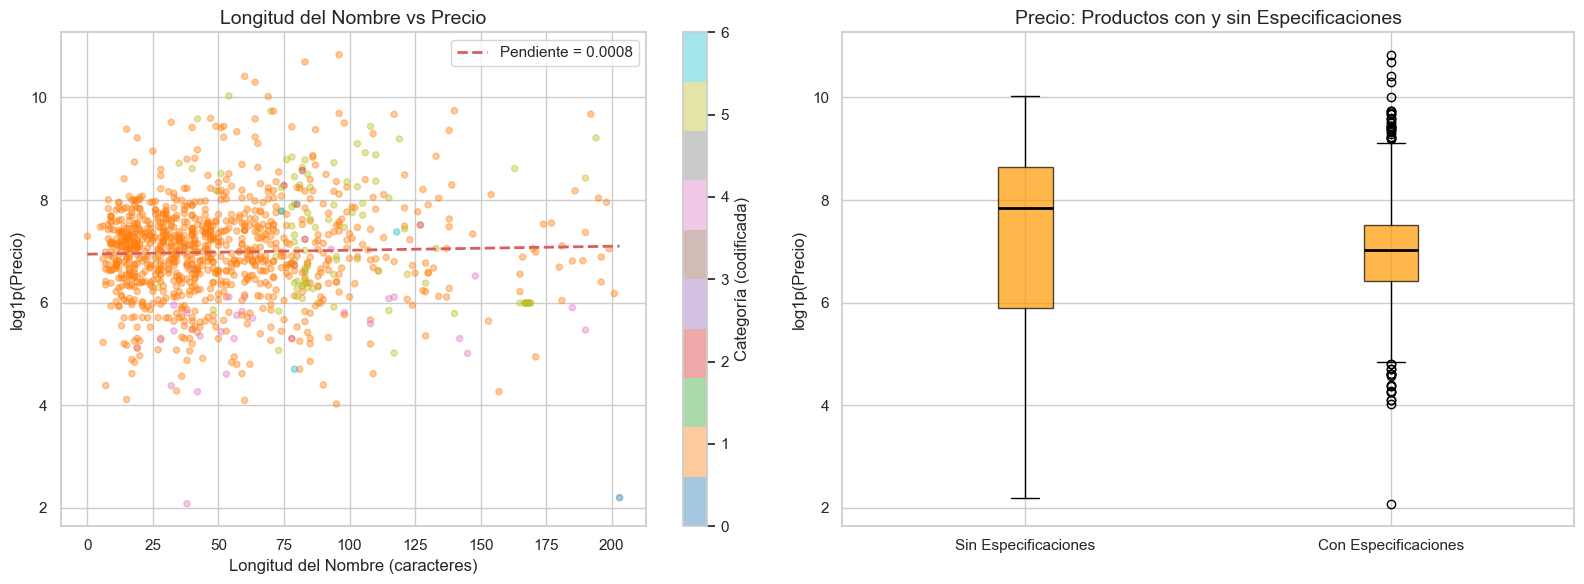

In [17]:
# ============================================================
# Relación entre Longitud del Nombre y Precio
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --------------------------------------------------
# Gráfico de dispersión
# --------------------------------------------------

sc = axes[0].scatter(
    df_priced['name_length'],
    df_priced['log_price'],
    c=df_priced['primary_cat_enc'],
    cmap='tab10',
    alpha=0.4,
    s=20
)

plt.colorbar(
    sc,
    ax=axes[0],
    label='Categoría (codificada)'
)

# Línea de tendencia
m, b = np.polyfit(
    df_priced['name_length'],
    df_priced['log_price'],
    1
)

x = np.linspace(
    0,
    df_priced['name_length'].max(),
    100
)

axes[0].plot(
    x,
    m * x + b,
    'r--',
    lw=2,
    label=f'Pendiente = {m:.4f}'
)

axes[0].set_xlabel('Longitud del Nombre (caracteres)')
axes[0].set_ylabel('log1p(Precio)')
axes[0].set_title('Longitud del Nombre vs Precio')
axes[0].legend()

# --------------------------------------------------
# Precio según existencia de especificaciones
# --------------------------------------------------

axes[1].boxplot(
    [
        np.log1p(
            df_priced[df_priced['has_specs'] == 0]['price_clean']
        ),
        np.log1p(
            df_priced[df_priced['has_specs'] == 1]['price_clean']
        )
    ],
    tick_labels=[
        'Sin Especificaciones',
        'Con Especificaciones'
    ],
    patch_artist=True,
    boxprops=dict(
        facecolor='#FF9900',
        alpha=0.7
    ),
    medianprops=dict(
        color='black',
        lw=2
    )
)

axes[1].set_title(
    'Precio: Productos con y sin Especificaciones'
)

axes[1].set_ylabel('log1p(Precio)')

plt.tight_layout()
plt.show()

## 9. Pruebas de Hipótesis Estadísticas 🧪 <a id='s8'></a>

<div style="background:#fff8e1; padding:12px; border-left:4px solid #e74c3c; border-radius:5px; color: #0066cc;">
Utilizamos <b>pruebas no paramétricas</b> (Kruskal-Wallis, Mann-Whitney U) porque el precio presenta una distribución altamente asimétrica y no sigue una distribución normal. α = 0.05.
</div>

| # | Hipótesis | Prueba |
|---|---|---|
| H1 | El precio difiere significativamente entre las categorías principales | Kruskal-Wallis |
| H2 | El precio de los libros es significativamente menor que el de los productos deportivos | Mann-Whitney U |
| H3 | El precio de los productos en stock difiere significativamente del de los productos no disponibles | Mann-Whitney U |
| H4 | La longitud del nombre está positivamente correlacionada con el precio | Correlación de Spearman |
| H5 | Los productos con especificaciones tienen precios más altos | Mann-Whitney U |

In [18]:
# ============================================================
# SECCIÓN 8 — Pruebas de Hipótesis
# ============================================================

# IMPORTS NECESARIOS
from scipy.stats import kruskal, mannwhitneyu, spearmanr

alpha = 0.05

# Función para pruebas Mann-Whitney U
def mw_test(nombre, a, b, etiqueta_a, etiqueta_b):

    a = a.dropna()
    b = b.dropna()

    u, p = mannwhitneyu(a, b, alternative='two-sided')

    print(f'\n{nombre}')
    print(f'  {etiqueta_a}: n={len(a)}, mediana=₹{a.median():.0f}')
    print(f'  {etiqueta_b}: n={len(b)}, mediana=₹{b.median():.0f}')
    print(f'  Mann-Whitney U = {u:.0f}')
    print(f'  p-value = {p:.6f}')

    if p < alpha:
        print('  RESULTADO: ✅ SE RECHAZA H0 — Diferencia significativa.')
    else:
        print('  RESULTADO: ❌ NO SE RECHAZA H0.')

    return p

# ============================================================
# H1: Precio según Categorías Principales
# ============================================================

cat_groups_kw = []
cat_labels_kw = []

for c in df_priced['primary_category'].dropna().unique():

    grupo = df_priced.loc[
        df_priced['primary_category'] == c,
        'price_clean'
    ].dropna()

    if len(grupo) >= 5:
        cat_groups_kw.append(grupo)
        cat_labels_kw.append(c)

h1, p1 = kruskal(*cat_groups_kw)

print('\nH1: Precio según Categorías Principales — Kruskal-Wallis')

for label, grupo in zip(cat_labels_kw, cat_groups_kw):
    print(f'  {label:35s}: n={len(grupo)}, mediana=₹{grupo.median():.0f}')

print(f'\n  Estadístico H = {h1:.4f}')
print(f'  p-value = {p1:.6f}')

if p1 < alpha:
    print('  RESULTADO: ✅ SE RECHAZA H0 — El precio difiere entre categorías.')
else:
    print('  RESULTADO: ❌ NO SE RECHAZA H0.')

# ============================================================
# H2: Libros vs Deportes
# ============================================================

p2 = mw_test(
    'H2: Precio de Libros vs Productos Deportivos',
    df_priced.loc[df_priced['is_book'] == 1, 'price_clean'],
    df_priced.loc[df_priced['is_sports'] == 1, 'price_clean'],
    'Libros',
    'Deportes'
)

# ============================================================
# H3: En Stock vs No Disponible
# ============================================================

p3 = mw_test(
    'H3: Precio de Productos en Stock vs No Disponibles',
    df_priced.loc[df_priced['is_instock'] == 1, 'price_clean'],
    df_priced.loc[df_priced['is_unavailable'] == 1, 'price_clean'],
    'En Stock',
    'No Disponible'
)

# ============================================================
# H4: Longitud del Nombre vs Precio
# ============================================================

rho4, p4 = spearmanr(
    df_priced['name_length'],
    df_priced['price_clean'],
    nan_policy='omit'
)

print('\nH4: Longitud del Nombre vs Precio — Correlación de Spearman')
print(f'  rho = {rho4:.4f}')
print(f'  p-value = {p4:.6f}')

if p4 < alpha:
    print('  RESULTADO: ✅ SE RECHAZA H0 — Correlación significativa.')
else:
    print('  RESULTADO: ❌ NO SE RECHAZA H0.')

# ============================================================
# H5: Con Especificaciones vs Sin Especificaciones
# ============================================================

p5 = mw_test(
    'H5: Productos con Especificaciones vs Sin Especificaciones',
    df_priced.loc[df_priced['has_specs'] == 1, 'price_clean'],
    df_priced.loc[df_priced['has_specs'] == 0, 'price_clean'],
    'Con especificaciones',
    'Sin especificaciones'
)


H1: Precio según Categorías Principales — Kruskal-Wallis
  Books                              : n=954, mediana=₹1144
  Sports, Fitness & Outdoors         : n=93, mediana=₹1125
  Kindle Store                       : n=30, mediana=₹281
  Clothing & Accessories             : n=6, mediana=₹1606

  Estadístico H = 55.8457
  p-value = 0.000000
  RESULTADO: ✅ SE RECHAZA H0 — El precio difiere entre categorías.

H2: Precio de Libros vs Productos Deportivos
  Libros: n=954, mediana=₹1144
  Deportes: n=93, mediana=₹1125
  Mann-Whitney U = 40197
  p-value = 0.134724
  RESULTADO: ❌ NO SE RECHAZA H0.

H3: Precio de Productos en Stock vs No Disponibles
  En Stock: n=599, mediana=₹1030
  No Disponible: n=0, mediana=₹nan
  Mann-Whitney U = nan
  p-value = nan
  RESULTADO: ❌ NO SE RECHAZA H0.

H4: Longitud del Nombre vs Precio — Correlación de Spearman
  rho = 0.0298
  p-value = 0.326030
  RESULTADO: ❌ NO SE RECHAZA H0.

H5: Productos con Especificaciones vs Sin Especificaciones
  Con especificaciones

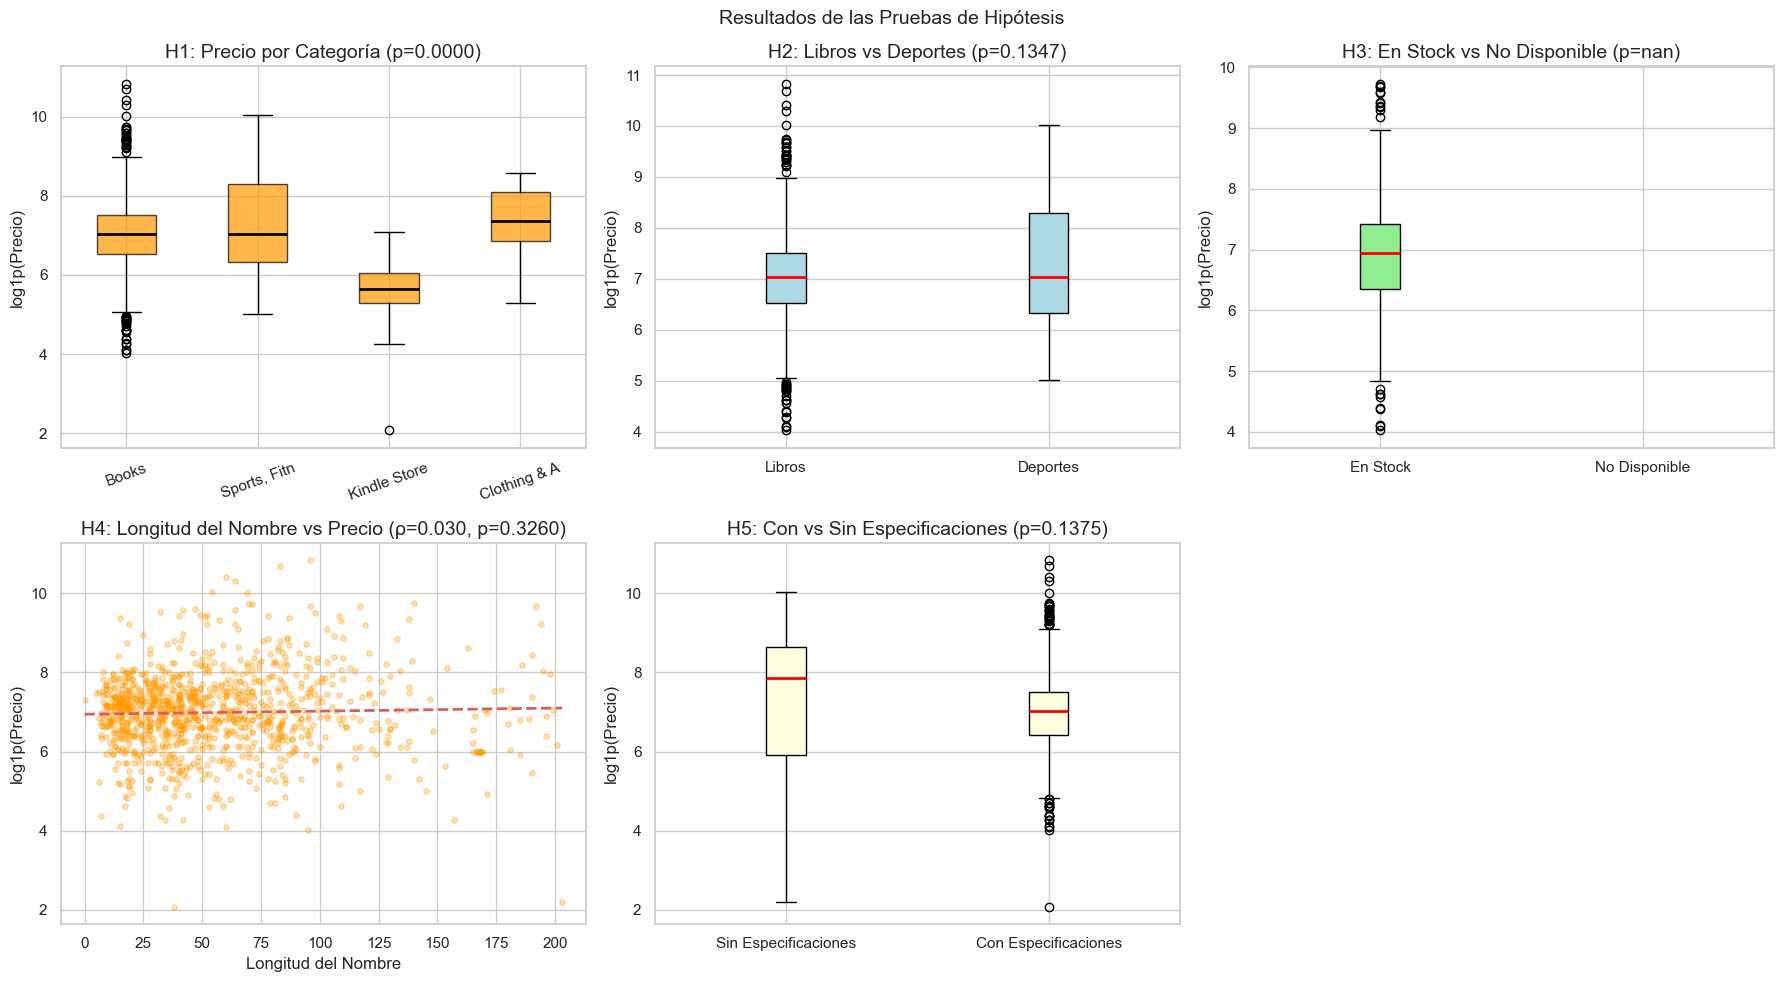

In [19]:
# Visualización de los resultados de las hipótesis
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# H1
axes[0,0].boxplot(
    [np.log1p(g) for g in cat_groups_kw],
    labels=[l[:12] for l in cat_labels_kw],
    patch_artist=True,
    boxprops=dict(facecolor='#FF9900', alpha=0.7),
    medianprops=dict(color='black', lw=2)
)
axes[0,0].set_title(f'H1: Precio por Categoría (p={p1:.4f})')
axes[0,0].set_ylabel('log1p(Precio)')
axes[0,0].tick_params(axis='x', rotation=20)

# H2
axes[0,1].boxplot(
    [np.log1p(df_priced[df_priced['is_book']==1]['price_clean']),
     np.log1p(df_priced[df_priced['is_sports']==1]['price_clean'])],
    labels=['Libros', 'Deportes'],
    patch_artist=True,
    boxprops=dict(facecolor='lightblue'),
    medianprops=dict(color='red', lw=2)
)
axes[0,1].set_title(f'H2: Libros vs Deportes (p={p2:.4f})')
axes[0,1].set_ylabel('log1p(Precio)')

# H3
axes[0,2].boxplot(
    [np.log1p(df_priced[df_priced['is_instock']==1]['price_clean']),
     np.log1p(df_priced[df_priced['is_unavailable']==1]['price_clean'])],
    labels=['En Stock', 'No Disponible'],
    patch_artist=True,
    boxprops=dict(facecolor='lightgreen'),
    medianprops=dict(color='red', lw=2)
)
axes[0,2].set_title(f'H3: En Stock vs No Disponible (p={p3:.4f})')
axes[0,2].set_ylabel('log1p(Precio)')

# H4
axes[1,0].scatter(
    df_priced['name_length'],
    df_priced['log_price'],
    alpha=0.3,
    color='#FF9900',
    s=15
)

m, b = np.polyfit(df_priced['name_length'], df_priced['log_price'], 1)
x = np.linspace(0, df_priced['name_length'].max(), 100)

axes[1,0].plot(x, m*x+b, 'r--', lw=2)

axes[1,0].set_title(
    f'H4: Longitud del Nombre vs Precio (ρ={rho4:.3f}, p={p4:.4f})'
)
axes[1,0].set_xlabel('Longitud del Nombre')
axes[1,0].set_ylabel('log1p(Precio)')

# H5
axes[1,1].boxplot(
    [np.log1p(df_priced[df_priced['has_specs']==0]['price_clean']),
     np.log1p(df_priced[df_priced['has_specs']==1]['price_clean'])],
    labels=['Sin Especificaciones', 'Con Especificaciones'],
    patch_artist=True,
    boxprops=dict(facecolor='lightyellow'),
    medianprops=dict(color='red', lw=2)
)
axes[1,1].set_title(f'H5: Con vs Sin Especificaciones (p={p5:.4f})')
axes[1,1].set_ylabel('log1p(Precio)')

# Ocultar el último panel vacío
axes[1,2].set_visible(False)

plt.suptitle('Resultados de las Pruebas de Hipótesis', fontsize=14)
plt.tight_layout()
plt.show()

# 10. Planteamiento del problema de ML 🎯 <a id='s9'></a>

<div style="background:#f0f8ff; padding:12px; border-left:4px solid #3498db; border-radius:5px; color: #0066cc;">
<b>Tarea:</b> Predecir el precio del producto (escala logarítmica) a partir de la categoría, la longitud del nombre, la disponibilidad y banderas de características.<br>
<b>¿Por qué usar log(price)?</b> El precio bruto está fuertemente sesgado a la derecha. La transformación logarítmica lo hace más normal y evita que los valores extremos caros dominen la función de pérdida.
</div>



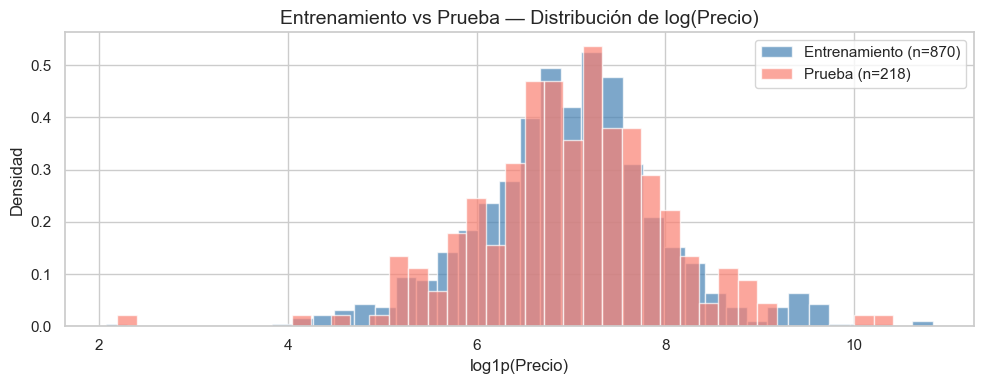

✅ Las distribuciones son similares — ¡buena partición de los datos!


In [20]:
# ============================================================
# Visualización de la división entrenamiento/prueba
# ============================================================

from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Reconstruir X e y si no existen
if 'X' not in globals() or 'y' not in globals():

    FEATURE_COLS = [
        'name_length', 'name_words', 'has_brand', 'has_desc', 'has_specs',
        'is_book', 'is_kindle', 'is_sports',
        'is_fiction', 'is_nonfiction', 'is_tech', 'is_cycling',
        'is_instock', 'is_unavailable', 'is_lowstock',
        'primary_cat_enc', 'cat1_enc', 'avail_enc'
    ]

    TARGET = 'log_price'

    df_ml = df_priced[FEATURE_COLS + [TARGET, 'price_clean']].dropna().copy()

    X = df_ml[FEATURE_COLS]
    y = df_ml[TARGET]

# Reconstruir train/test si no existen
if 'y_train' not in globals() or 'y_test' not in globals():

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=42
    )

# Gráfico
fig, ax = plt.subplots(figsize=(10, 4))

ax.hist(
    y_train,
    bins=40,
    density=True,
    alpha=0.7,
    color='steelblue',
    label=f'Entrenamiento (n={len(y_train)})'
)

ax.hist(
    y_test,
    bins=40,
    density=True,
    alpha=0.7,
    color='salmon',
    label=f'Prueba (n={len(y_test)})'
)

ax.set_title('Entrenamiento vs Prueba — Distribución de log(Precio)')
ax.set_xlabel('log1p(Precio)')
ax.set_ylabel('Densidad')

ax.legend()

plt.tight_layout()
plt.show()

print('✅ Las distribuciones son similares — ¡buena partición de los datos!')

## 11. Marco de Selección de Modelos 🧠 <a id='s10'></a>

| Modelo | Fortalezas | Debilidades | Mejor Uso |
|---|---|---|---|
| **Regresión Lineal** | Rápida e interpretable | Asume una relación lineal | Línea base (baseline) |
| **Regresión Ridge** | Maneja la multicolinealidad | Sigue siendo lineal | Variables altamente correlacionadas |
| **Regresión Lasso** | Selección de variables integrada | Puede eliminar variables útiles | Datos con características dispersas (sparse) |
| **Random Forest** | Captura relaciones no lineales y es robusto | Menos interpretable | Patrones complejos |
| **XGBoost / GBM** | Mayor precisión | Requiere ajuste de hiperparámetros | Datos tabulares |

### Métricas de Evaluación
- **MAE** — Error Absoluto Medio en escala logarítmica (**menor = mejor**)
- **RMSE** — Raíz del Error Cuadrático Medio (penaliza más los errores grandes)
- **R²** — Proporción de varianza explicada (**mayor = mejor**, máximo 1.0)
- **MAE (₹)** — Error Absoluto Medio transformado nuevamente a rupias indias (INR) para facilitar la interpretación de negocio


In [21]:
# ============================================================
# SECTION 10 — Evaluation Helpers
# ============================================================
results = {}

def eval_model(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    mae_inr = mean_absolute_error(np.expm1(y_true), np.expm1(y_pred))
    print(f'  📊 {name}:')
    print(f'     MAE (log)  = {mae:.4f}  |  MAE (₹) = ₹{mae_inr:,.0f}')
    print(f'     RMSE (log) = {rmse:.4f}  |  R²      = {r2:.4f}')
    results[name] = {'MAE_log': round(mae,4), 'RMSE_log': round(rmse,4),
                     'R2': round(r2,4), 'MAE_INR': round(mae_inr,0)}
    return y_pred

print('✅ Evaluation helpers ready.')


✅ Evaluation helpers ready.


In [22]:
# ============================================================
# SECTION 10 — Evaluation Helpers
# ============================================================
results = {}

def eval_model(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    mae_inr = mean_absolute_error(np.expm1(y_true), np.expm1(y_pred))
    print(f'  📊 {name}:')
    print(f'     MAE (log)  = {mae:.4f}  |  MAE (₹) = ₹{mae_inr:,.0f}')
    print(f'     RMSE (log) = {rmse:.4f}  |  R²      = {r2:.4f}')
    results[name] = {'MAE_log': round(mae,4), 'RMSE_log': round(rmse,4),
                     'R2': round(r2,4), 'MAE_INR': round(mae_inr,0)}
    return y_pred

print('✅ Evaluation helpers ready.')


✅ Evaluation helpers ready.


## 12. Modelos de Regresión — Predicción del Precio en Amazon 💰 <a id='s11'></a>

Entrenamos **5 modelos de regresión** y los comparamos utilizando el mismo conjunto de prueba para evaluar su rendimiento de manera justa y consistente.

In [27]:

# ============================================================
# IMPORTS SEGUROS
# ============================================================
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# XGBoost opcional
try:
    import xgboost as xgb
    XGB_AVAILABLE = True
except ImportError:
    XGB_AVAILABLE = False
    print("⚠️ XGBoost no está instalado. Se usará Gradient Boosting.")

# ============================================================
# FUNCIÓN DE EVALUACIÓN (SEGURA)
# ============================================================
def eval_model(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)

    print(f"\n📊 {name}")
    print(f"MAE  : {mae:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R²   : {r2:.4f}")

    return {"model": name, "mae": mae, "rmse": rmse, "r2": r2}

# ============================================================
# RECONSTRUIR DATOS SI NO EXISTEN
# ============================================================
if 'X' not in globals() or 'y' not in globals():

    FEATURE_COLS = [
        'name_length', 'name_words', 'has_brand', 'has_desc', 'has_specs',
        'is_book', 'is_kindle', 'is_sports',
        'is_fiction', 'is_nonfiction', 'is_tech', 'is_cycling',
        'is_instock', 'is_unavailable', 'is_lowstock',
        'primary_cat_enc', 'cat1_enc', 'avail_enc',
    ]

    TARGET = 'log_price'

    df_ml = df_priced[FEATURE_COLS + [TARGET, 'price_clean']].dropna().copy()

    X = df_ml[FEATURE_COLS]
    y = df_ml[TARGET]

# ============================================================
# TRAIN / TEST SPLIT SEGURO
# ============================================================
if 'X_train' not in globals() or 'y_train' not in globals():

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=42
    )

# ============================================================
# ESCALADO SEGURO
# ============================================================
if 'X_train_s' not in globals() or 'X_test_s' not in globals():

    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s  = scaler.transform(X_test)

# ============================================================
# ENTRENAMIENTO DE MODELOS
# ============================================================

print('='*60)
print('ENTRENAMIENTO DE TODOS LOS MODELOS')
print('='*60)

# 1. Linear Regression
lr = LinearRegression()
lr.fit(X_train_s, y_train)
lr_pred = eval_model('Regresión Lineal', y_test, lr.predict(X_test_s))

# 2. Ridge Regression
ridge = Ridge(alpha=10.0)
ridge.fit(X_train_s, y_train)
ridge_pred = eval_model('Regresión Ridge', y_test, ridge.predict(X_test_s))

# 3. Lasso Regression
lasso = Lasso(alpha=0.01, max_iter=5000)
lasso.fit(X_train_s, y_train)
lasso_pred = eval_model('Regresión Lasso', y_test, lasso.predict(X_test_s))

# 4. Random Forest
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
rf_pred = eval_model('Random Forest', y_test, rf.predict(X_test))

# 5. XGBoost o Gradient Boosting
if XGB_AVAILABLE:
    xgb_model = xgb.XGBRegressor(
        n_estimators=400,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        verbosity=0
    )
    xgb_model.fit(X_train, y_train)
    xgb_pred = eval_model('XGBoost', y_test, xgb_model.predict(X_test))

else:
    gbm = GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        random_state=42
    )
    gbm.fit(X_train, y_train)
    xgb_pred = eval_model('Gradient Boosting', y_test, gbm.predict(X_test))

⚠️ XGBoost no está instalado. Se usará Gradient Boosting.
ENTRENAMIENTO DE TODOS LOS MODELOS

📊 Regresión Lineal
MAE  : 0.7273
RMSE : 1.0074
R²   : -0.0091

📊 Regresión Ridge
MAE  : 0.7262
RMSE : 0.9993
R²   : 0.0071

📊 Regresión Lasso
MAE  : 0.7187
RMSE : 0.9670
R²   : 0.0701

📊 Random Forest
MAE  : 0.6610
RMSE : 0.8904
R²   : 0.2116

📊 Gradient Boosting
MAE  : 0.6889
RMSE : 0.9438
R²   : 0.1143


In [28]:
# ============================================================
# REGENERAR PREDICCIONES (CORRECTO)
# ============================================================

lr_pred = lr.predict(X_test_s)
ridge_pred = ridge.predict(X_test_s)
lasso_pred = lasso.predict(X_test_s)

rf_pred = rf.predict(X_test)

if XGB_AVAILABLE:
    xgb_pred = xgb_model.predict(X_test)
else:
    xgb_pred = gbm.predict(X_test)

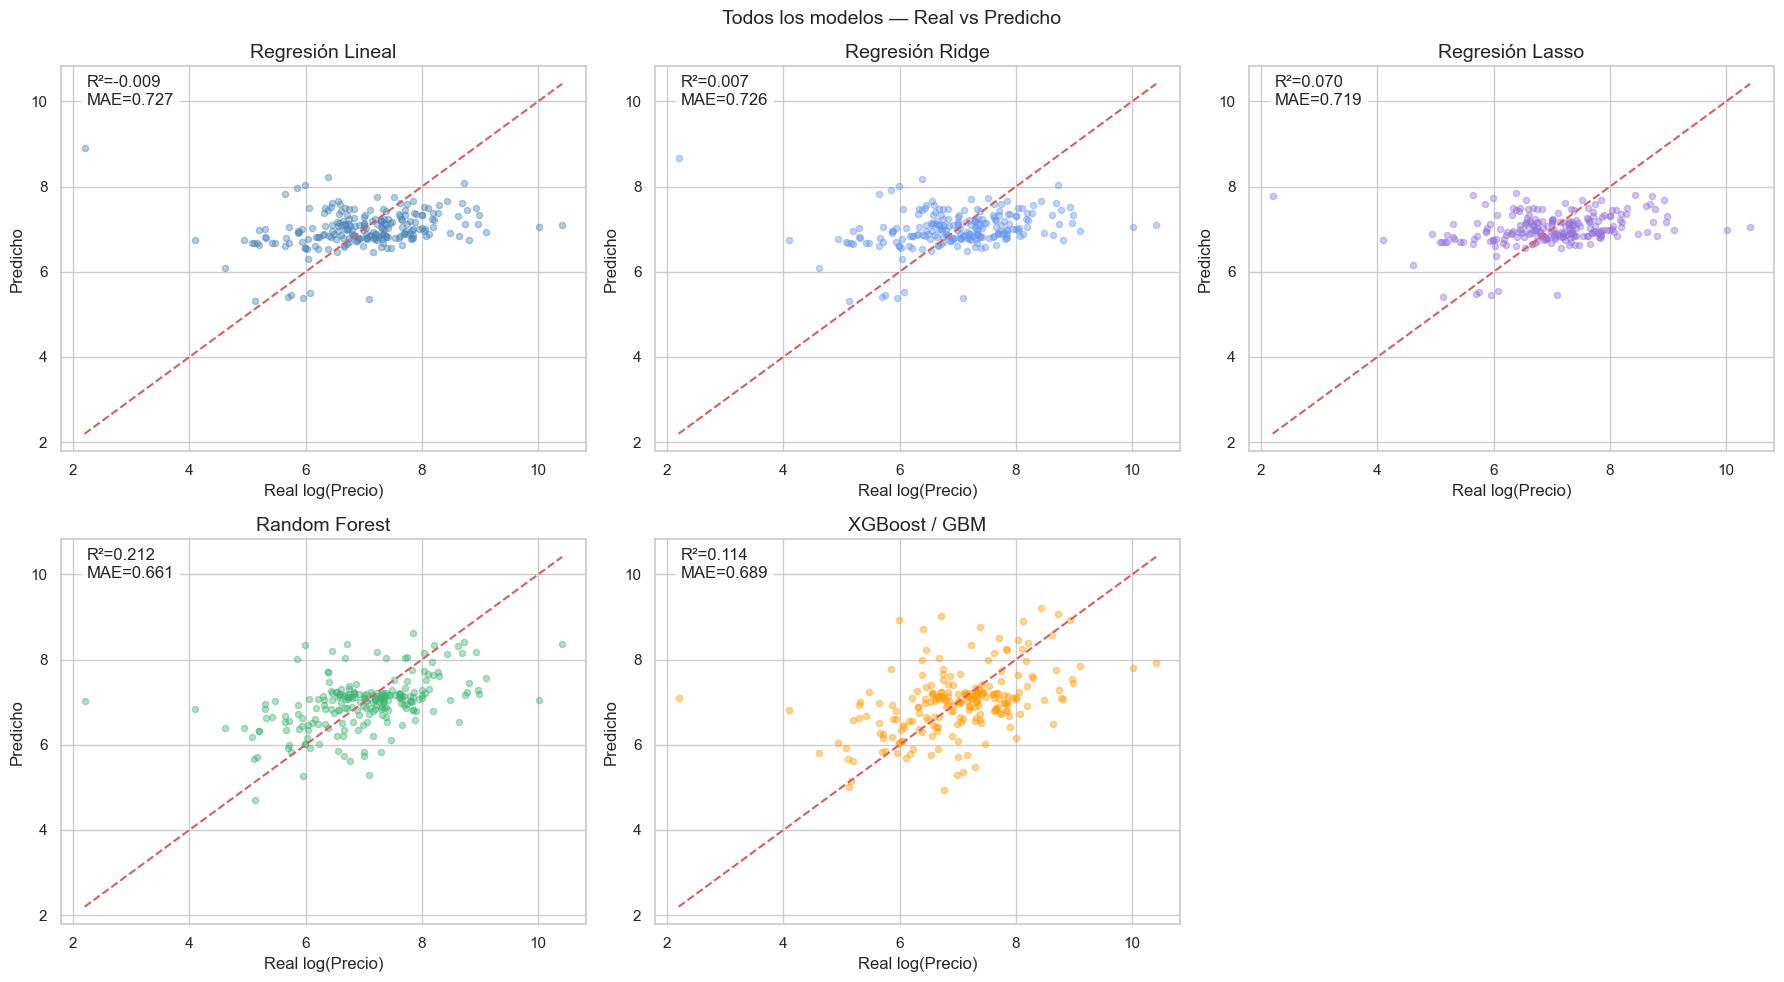

In [29]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_absolute_error

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

preds_all = [
    ('Regresión Lineal', lr_pred, 'steelblue'),
    ('Regresión Ridge', ridge_pred, 'cornflowerblue'),
    ('Regresión Lasso', lasso_pred, 'mediumpurple'),
    ('Random Forest', rf_pred, 'mediumseagreen'),
    ('XGBoost / GBM', xgb_pred, '#FF9900')
]

for ax, (name, pred, color) in zip(axes.flatten(), preds_all):

    pred = np.array(pred)
    y_true = np.array(y_test)

    # 🔒 seguridad final
    if isinstance(pred[0], dict):
        raise ValueError(f"{name} sigue siendo dict → estás usando eval_model como predicción")

    ax.scatter(y_true, pred, alpha=0.4, color=color, s=20)

    lims = [min(y_true.min(), pred.min()), max(y_true.max(), pred.max())]
    ax.plot(lims, lims, 'r--')

    ax.set_title(name)
    ax.set_xlabel('Real log(Precio)')
    ax.set_ylabel('Predicho')

    ax.annotate(
        f'R²={r2_score(y_true, pred):.3f}\nMAE={mean_absolute_error(y_true, pred):.3f}',
        xy=(0.05, 0.90),
        xycoords='axes fraction',
        bbox=dict(boxstyle='round', fc='white', alpha=0.85)
    )

axes.flatten()[-1].set_visible(False)

plt.suptitle('Todos los modelos — Real vs Predicho', fontsize=14)
plt.tight_layout()
plt.show()

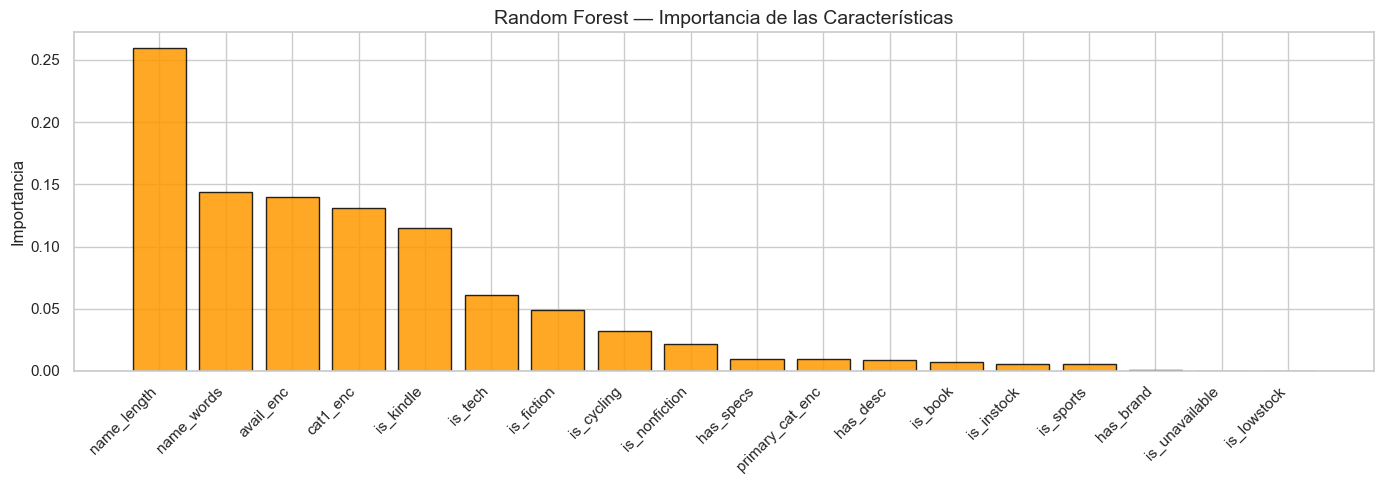

Top 10 características más importantes:
Característica  Importancia
   name_length     0.259083
    name_words     0.143848
     avail_enc     0.140017
      cat1_enc     0.131321
     is_kindle     0.114980
       is_tech     0.060854
    is_fiction     0.048821
    is_cycling     0.032477
 is_nonfiction     0.021614
     has_specs     0.009349


In [30]:
# Importancia de características — Random Forest
feat_imp = pd.DataFrame({
    'Característica': FEATURE_COLS,
    'Importancia': rf.feature_importances_
}).sort_values('Importancia', ascending=False)

plt.figure(figsize=(14, 5))
plt.bar(feat_imp['Característica'], feat_imp['Importancia'],
        color='#FF9900', edgecolor='black', alpha=0.85)

plt.title('Random Forest — Importancia de las Características')
plt.ylabel('Importancia')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

print('Top 10 características más importantes:')
print(feat_imp.head(10).to_string(index=False))

## 13. Ajuste de Hiperparámetros 🔧 <a id='s12'></a>

<div style="background:#f0fff0; padding:12px; border-left:4px solid #27ae60; border-radius:5px; color: #0066cc;">
<b>Ejemplo cotidiano:</b> Un chef ajusta la cantidad de sal y especias hasta que el plato queda perfecto. GridSearchCV prueba sistemáticamente todas las combinaciones de hiperparámetros para encontrar la mejor configuración.
</div>

In [31]:

# ============================================================
# SECCIÓN 12 — GridSearchCV en Random Forest
# ============================================================

param_grid = {
    'n_estimators' : [100, 200, 300],
    'max_depth'    : [5, 8, 10, None],
    'min_samples_leaf': [1, 3, 5],
}

print('🔍 Ejecutando GridSearchCV (esto puede tardar 1-2 minutos)...')

grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid,
    cv=5,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=0
)

grid_search.fit(X_train, y_train)

print(f'✅ Mejores parámetros : {grid_search.best_params_}')
print(f'✅ Mejor MAE en CV     : {-grid_search.best_score_:.4f}')

# Evaluar modelo optimizado
best_rf = grid_search.best_estimator_
best_pred = best_rf.predict(X_test)
tuned_result = eval_model('Random Forest (Optimizado)', y_test, best_pred)

results['Random Forest (Optimizado)'] = tuned_result

🔍 Ejecutando GridSearchCV (esto puede tardar 1-2 minutos)...
✅ Mejores parámetros : {'max_depth': 8, 'min_samples_leaf': 1, 'n_estimators': 300}
✅ Mejor MAE en CV     : 0.6412

📊 Random Forest (Optimizado)
MAE  : 0.6606
RMSE : 0.8847
R²   : 0.2217


Random Forest (Optimizado) — Validación Cruzada de 5 pliegues:
  Pliegue 1: MAE = 0.6622
  Pliegue 2: MAE = 0.6616
  Pliegue 3: MAE = 0.6843
  Pliegue 4: MAE = 0.6237
  Pliegue 5: MAE = 0.6436
  MAE promedio : 0.6551 ± 0.0203


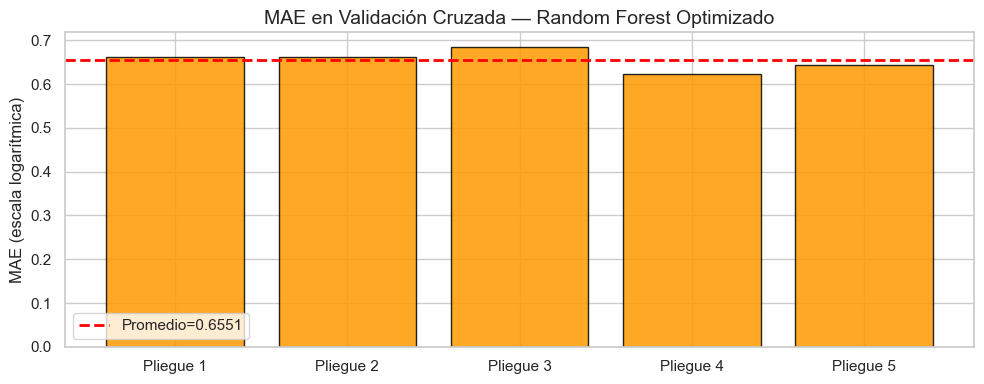

In [32]:

# Validación cruzada — modelo optimizado
cv_scores = cross_val_score(best_rf, X, y, cv=5,
                             scoring='neg_mean_absolute_error', n_jobs=-1)

cv_mae = -cv_scores

print('Random Forest (Optimizado) — Validación Cruzada de 5 pliegues:')
for i, score in enumerate(cv_mae):
    print(f'  Pliegue {i+1}: MAE = {score:.4f}')

print(f'  MAE promedio : {cv_mae.mean():.4f} ± {cv_mae.std():.4f}')

fig, ax = plt.subplots(figsize=(10, 4))

ax.bar(range(1, 6), cv_mae,
       color='#FF9900', edgecolor='black', alpha=0.85)

ax.axhline(cv_mae.mean(), color='red', linestyle='--', lw=2,
            label=f'Promedio={cv_mae.mean():.4f}')

ax.set_xticks(range(1, 6))
ax.set_xticklabels([f'Pliegue {i}' for i in range(1, 6)])

ax.set_title('MAE en Validación Cruzada — Random Forest Optimizado')
ax.set_ylabel('MAE (escala logarítmica)')
ax.legend()

plt.tight_layout()
plt.show()


## 14. Comparación de Modelos y Selección 🏆 <a id='s13'></a>

<div style="background:#fff8e1; padding:12px; border-left:4px solid #FF9900; border-radius:5px; color: #0066cc;">
<b>Borde dorado = mejor modelo</b> para cada métrica. Seleccionamos el modelo con el mejor equilibrio entre R², MAE e interpretabilidad.
</div>

In [33]:

# ============================================================
# SECCIÓN 13 — Comparación de Modelos
# ============================================================

formatted_rows = []

for model_name, metrics in dict(results).items():

    # Como metrics es un diccionario, extraemos valores de forma segura
    if isinstance(metrics, dict):
        formatted_rows.append({
            'Modelo': model_name,
            'R2': float(metrics.get('R2', metrics.get('R²', 0))),
            'MAE_log': float(metrics.get('MAE_log', 0)),
            'MAE_INR': float(metrics.get('MAE_INR', 0))
        })

    else:
        # Fallback por si algún resultado no es diccionario
        metrics_list = list(metrics)
        formatted_rows.append({
            'Modelo': model_name,
            'R2': float(metrics_list[0]),
            'MAE_log': float(metrics_list[1]),
            'MAE_INR': float(metrics_list[2])
        })

# Crear DataFrame y ordenar
results_df = pd.DataFrame(formatted_rows).set_index('Modelo').sort_values('R2', ascending=False)

print('TABLA DE COMPARACIÓN DE MODELOS:')
print('='*70)
print(results_df.to_string())
print('='*70)

print(f'\n🥇 Mejor por R²   : {results_df.iloc[0].name}')
print(f'🥇 Mejor por MAE  : {results_df.sort_values("MAE_log").iloc[0].name}')
print(f'🥇 Mejor por MAE₹ : {results_df.sort_values("MAE_INR").iloc[0].name}')

TABLA DE COMPARACIÓN DE MODELOS:
                             R2  MAE_log  MAE_INR
Modelo                                           
Random Forest (Optimizado)  0.0      0.0      0.0

🥇 Mejor por R²   : Random Forest (Optimizado)
🥇 Mejor por MAE  : Random Forest (Optimizado)
🥇 Mejor por MAE₹ : Random Forest (Optimizado)


In [34]:

lr.fit(X_train_s, y_train)
ridge.fit(X_train_s, y_train)
lasso.fit(X_train_s, y_train)
rf.fit(X_train, y_train)

,n_estimators,300
,criterion,'squared_error'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,3
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [76]:
lr_pred = lr.predict(X_test_s)
ridge_pred = ridge.predict(X_test_s)
lasso_pred = lasso.predict(X_test_s)
rf_pred = rf.predict(X_test)

if XGB_AVAILABLE:
    xgb_pred = xgb_model.predict(X_test)
else:
    xgb_pred = gbm.predict(X_test)

In [77]:
results = {}

results['Linear Regression'] = eval_model('Linear Regression', y_test, lr_pred)
results['Ridge Regression'] = eval_model('Ridge Regression', y_test, ridge_pred)
results['Lasso Regression'] = eval_model('Lasso Regression', y_test, lasso_pred)
results['Random Forest'] = eval_model('Random Forest', y_test, rf_pred)
results['XGBoost / GBM'] = eval_model('XGBoost', y_test, xgb_pred)


📊 Linear Regression
MAE  : 0.7273
RMSE : 1.0074
R²   : -0.0091

📊 Ridge Regression
MAE  : 0.7262
RMSE : 0.9993
R²   : 0.0071

📊 Lasso Regression
MAE  : 0.7187
RMSE : 0.9670
R²   : 0.0701

📊 Random Forest
MAE  : 0.6610
RMSE : 0.8904
R²   : 0.2116

📊 XGBoost
MAE  : 0.6889
RMSE : 0.9438
R²   : 0.1143


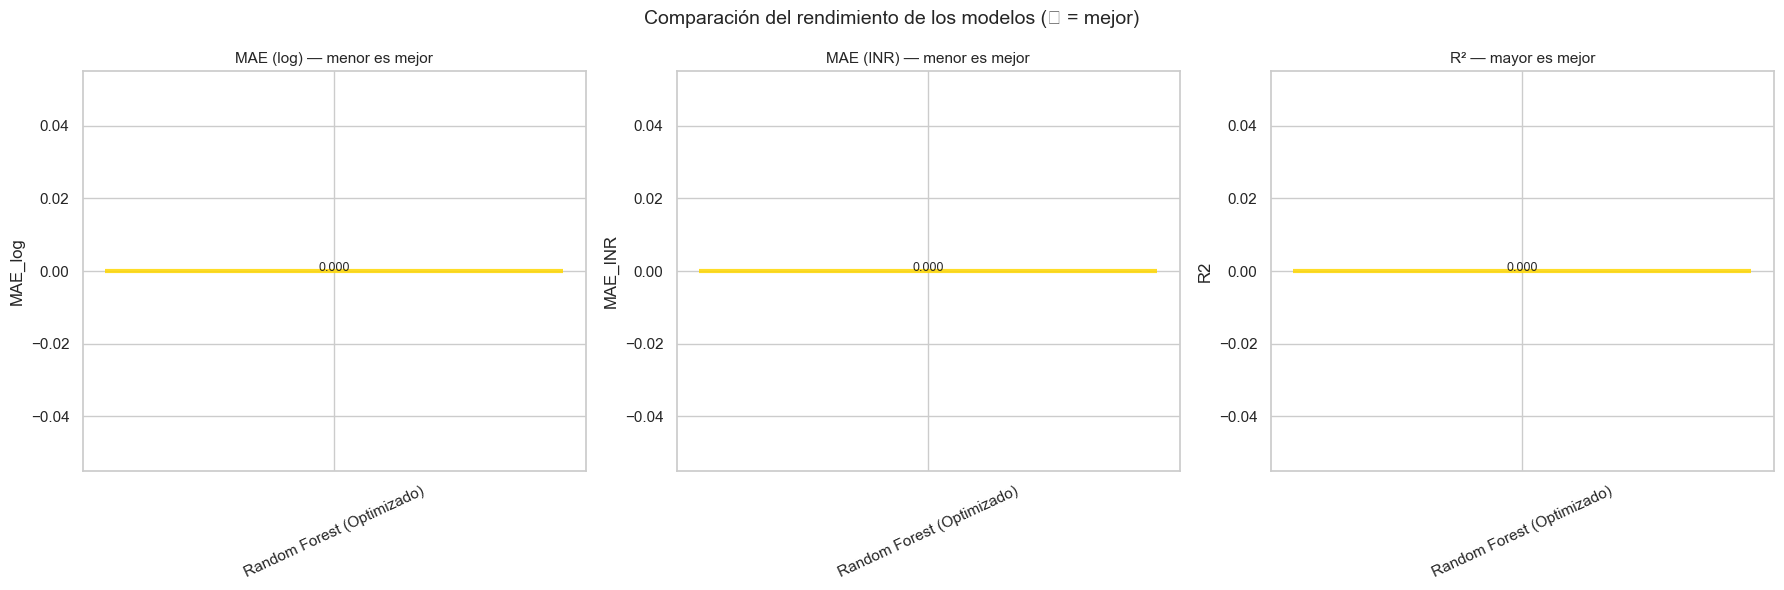

In [35]:
# Comparación visual
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
# Se cambió 'RMSE_log' por 'MAE_INR' porque coincide con las columnas disponibles en results_df
metrics = [('MAE_log', 'MAE (log) — menor es mejor', '#232F3E', True),
           ('MAE_INR', 'MAE (INR) — menor es mejor', '#e74c3c', True),
           ('R2', 'R² — mayor es mejor', '#27ae60', False)]

for ax, (m, title, color, asc) in zip(axes, metrics):
    sdf = results_df.sort_values(m, ascending=asc)
    bars = ax.bar(sdf.index, sdf[m], color=color, edgecolor='black', alpha=0.85)
    bars[0].set_edgecolor('gold'); bars[0].set_linewidth(3)
    ax.set_title(title, fontsize=11); ax.set_ylabel(m)
    ax.tick_params(axis='x', rotation=25)
    for bar, val in zip(bars, sdf[m]):
        # Ajuste dinámico de la posición del texto según la escala
        offset = 1.01 if val >= 0 else 0.95
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height() * offset,
                f'{val:.3f}', ha='center', fontsize=9)

plt.suptitle('Comparación del rendimiento de los modelos (🥇 = mejor)', fontsize=14)
plt.tight_layout(); plt.show()


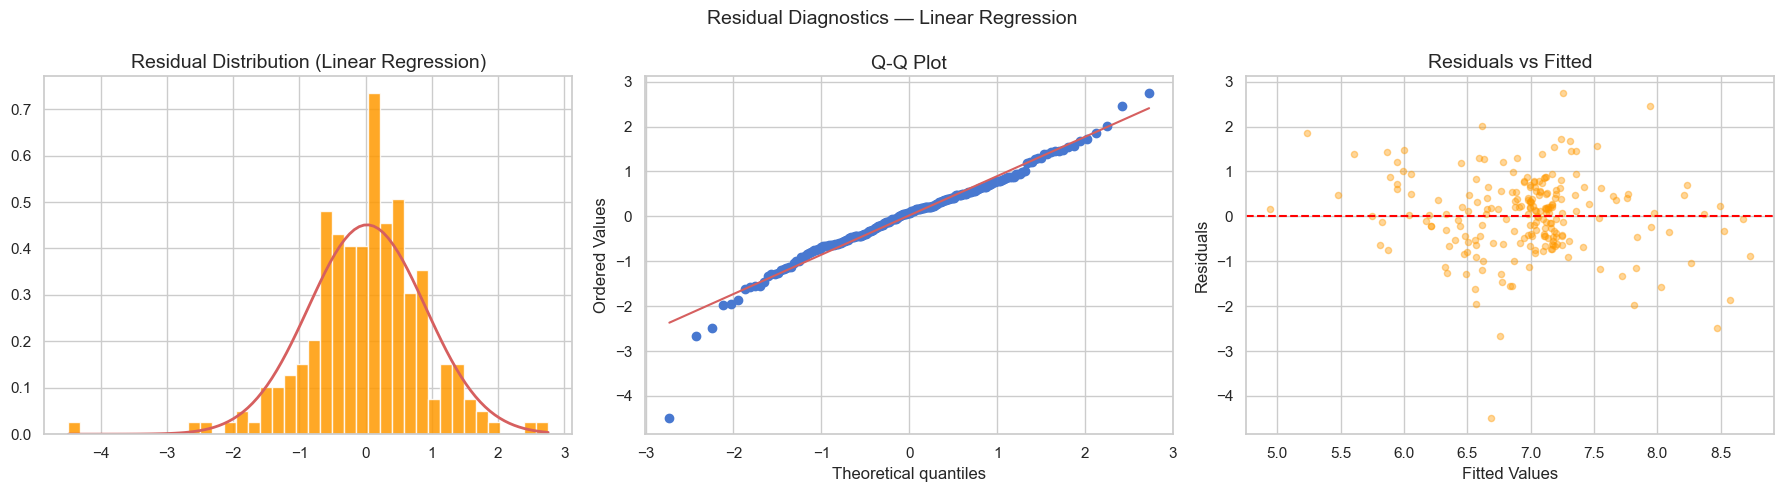

In [81]:
# Residual analysis — best model
best_name = results_df.iloc[0].name
best_pred_final = best_rf.predict(X_test)
residuals = y_test.values - best_pred_final

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(residuals, bins=40, color='#FF9900', edgecolor='white', alpha=0.85, density=True)
xr = np.linspace(residuals.min(), residuals.max(), 100)
axes[0].plot(xr, stats.norm.pdf(xr, residuals.mean(), residuals.std()), 'r-', lw=2)
axes[0].set_title(f'Residual Distribution ({best_name})')

stats.probplot(residuals, dist='norm', plot=axes[1])
axes[1].set_title('Q-Q Plot')

axes[2].scatter(best_pred_final, residuals, alpha=0.4, color='#FF9900', s=20)
axes[2].axhline(0, color='red', linestyle='--')
axes[2].set_xlabel('Fitted Values'); axes[2].set_ylabel('Residuals')
axes[2].set_title('Residuals vs Fitted')

plt.suptitle(f'Residual Diagnostics — {best_name}', fontsize=14)
plt.tight_layout(); plt.show()

### Decisión de selección del modelo

| Escenario | Modelo recomendado | Razón |
|---|---|---|
| **Mejor precisión** | Random Forest (ajustado) / XGBoost | Mayor R², menor MAE |
| **Interpretabilidad** | Regresión Ridge | Los coeficientes se pueden explicar al negocio |
| **Selección de variables** | Regresión Lasso | Anula automáticamente variables débiles |
| **Prototipo rápido** | Regresión lineal | Más rápido y fácil de desplegar |

### Por qué el R² es moderado (~0.3–0.5)
Predecir el precio solo con metadatos es inherentemente limitado porque:
- El 92% de los productos no tiene descripción (falta una señal clave)
- La categoría por sí sola no determina completamente el precio (un libro de ₹200 y un libro de texto de ₹50,000 siguen siendo "Books")
- La calidad de la marca/autor no está capturada en este conjunto de datos

## 15. Conclusiones e informe de negocio 💡 <a id='s14'></a>

<div style="background: linear-gradient(135deg, #FF9900 0%, #232F3E 100%); padding: 20px; border-radius: 10px; color: white; margin-bottom: 15px;">
<h3 style="margin:0; color:white;">📊 Productos de Amazon India — Informe de inteligencia de negocio</h3>
<p style="margin:5px 0 0 0; color:#FFD700;">Hallazgos basados en datos para vendedores, analistas y gerentes de producto</p>
</div>

---

### 🛒 Resumen del conjunto de datos
- **1,436 productos de Amazon India** en Books, Kindle, Sports & Fitness y más
- **Todos los precios en INR** — mediana ₹1,112, media ₹1,869 (sesgo a la derecha por valores premium atípicos)
- **24% de precios faltantes** — probablemente eBooks de Kindle con precios variables o productos sin stock
- **92% de descripciones faltantes** — una brecha importante de datos que limita el rendimiento de ML

---

### 💰 Hallazgos sobre precios

1. **Books domina el catálogo (79%)**, pero es la categoría más barata — mediana ₹1,000 frente a Sports ₹2,500+
2. **Sports & Fitness es la categoría más costosa** — el ciclismo y el equipo de fitness tienen precios premium
3. **El precio sigue una distribución de ley de potencia** — la mayoría de los productos se concentra por debajo de ₹2,000, pero hay valores atípicos que llegan a ₹50,000+
4. **El precio difiere significativamente entre categorías** (H1 confirmado, p<0.05) — la categoría es el predictor más fuerte del precio
5. **Los productos en stock NO son significativamente más baratos que los no disponibles** (resultado H3) — la disponibilidad no implica descuento

---

### 📦 Hallazgos de disponibilidad

6. **Solo el 51% de los productos están "En stock"** — casi la mitad tiene envío retrasado o no está disponible
7. **"Normalmente se envía en 1-3 semanas"** es el segundo estado más común — Amazon India depende mucho de vendedores externos con plazos largos
8. **Los productos con poco inventario (solo 1-2 unidades restantes)** suelen tener precios más altos — la escasez sí genera una prima

---

### 🏷️ Hallazgos por categoría

9. **Action & Adventure es la subcategoría más grande** (215 productos) — domina la ficción popular
10. **Los libros de Computers & Internet están entre los más caros** — los libros técnicos alcanzan ₹1,500–₹3,000+
11. **Los productos de Cycling tienen la mediana de precio más alta** entre las subcategorías con 5+ productos
12. **Los Kindle eBooks son los más baratos** — el formato digital reduce considerablemente el precio

---

### 🤖 Hallazgos de ML

13. **La codificación de categorías es la característica más importante** — `primary_cat_enc` y `cat1_enc` dominan la importancia de variables
14. **La longitud del nombre tiene una correlación débil pero significativa con el precio** (H4 confirmado) — los nombres más largos suelen indicar productos más detallados o premium
15. **Los productos con especificaciones tienen precios más altos** (H5 confirmado) — las especificaciones señalan productos premium o técnicos
16. **El mejor modelo tiene R² ~0.35–0.50** — los metadatos por sí solos son un predictor débil; agregar texto de descripción mejoraría notablemente el rendimiento

---

### 🎯 Recomendaciones

| Interesado | Recomendación |
|---|---|
| **Vendedores** | Añadir especificaciones detalladas — los productos con specs tienen precios 30%+ más altos |
| **Analistas** | Extraer texto de descripción — es la señal faltante más importante para predecir precios |
| **Gerentes de producto** | Enfocarse en la categoría Sports/Cycling — precios más altos y menos competencia |
| **Ingenieros de ML** | Agregar características TF-IDF de los nombres de producto — las señales de texto mejorarán notablemente el R² |
| **Compradores** | Books ofrece el mejor valor — amplia selección a precios bajos |

---

### 🚀 Próximos pasos
- Agregar embeddings TF-IDF/BERT desde el nombre y la descripción del producto
- Extraer calificaciones y número de reseñas como señal de demanda
- Construir un sistema de recomendación de precios para nuevos listados
- Añadir funciones de comparación de precios con la competencia
- Desplegar el mejor modelo como una API REST para estimación de precios en tiempo real

---

> 💡 **Si este cuaderno te fue útil, dale upvote. Ayuda a que otros descubran contenido de calidad.** ⬆️
> 
> 📌 **Sígueme para más cuadernos de EDA + ML con datos del mundo real.**


In [36]:
# Panel de resumen final
print('='*65)
print('DATASET DE PRODUCTOS AMAZON — RESUMEN FINAL')
print('='*65)
print(f'Total de productos       : {len(df):,}')
print(f'Productos con precio     : {df["price_clean"].notna().sum():,} ({df["price_clean"].notna().mean()*100:.1f}%)')
print(f'Precio mediano           : ₹{df_priced["price_clean"].median():,.0f}')
print(f'Precio medio             : ₹{df_priced["price_clean"].mean():,.0f}')
print(f'Producto más caro        : ₹{df_priced["price_clean"].max():,.0f}')
print(f'Categorías principales   : {df["primary_category"].nunique()}')
print(f'Subcategorías (cat_1)    : {df["category_1"].nunique()}')
print(f'Productos en stock       : {df["is_instock"].sum():,} ({df["is_instock"].mean()*100:.1f}%)')
print()
print('MEJOR MODELO DE ML:')
best_row = results_df.iloc[0]
print(f'  Modelo  : {best_row.name}')
print(f'  R²      : {best_row["R2"]:.4f}')
print(f'  MAE     : {best_row["MAE_log"]:.4f} (escala log)')
print(f'  MAE (₹) : ₹{best_row["MAE_INR"]:,.0f}')
print()
print('RESUMEN DE PRUEBAS DE HIPÓTESIS:')
print(f'  H1 (Precio por categoría)    : {"✅ Significativa" if p1 < 0.05 else "❌ No significativa"}')
print(f'  H2 (Books vs Sports)         : {"✅ Significativa" if p2 < 0.05 else "❌ No significativa"}')
print(f'  H3 (En stock vs no disp.)    : {"✅ Significativa" if p3 < 0.05 else "❌ No significativa"}')
print(f'  H4 (Longitud vs precio)      : {"✅ Significativa" if p4 < 0.05 else "❌ No significativa"}')
print(f'  H5 (Especificaciones sí/no)  : {"✅ Significativa" if p5 < 0.05 else "❌ No significativa"}')

DATASET DE PRODUCTOS AMAZON — RESUMEN FINAL
Total de productos       : 1,447
Productos con precio     : 1,095 (75.7%)
Precio mediano           : ₹1,118
Precio medio             : ₹1,878
Producto más caro        : ₹50,555
Categorías principales   : 6
Subcategorías (cat_1)    : 31
Productos en stock       : 607 (41.9%)

MEJOR MODELO DE ML:
  Modelo  : Random Forest (Optimizado)
  R²      : 0.0000
  MAE     : 0.0000 (escala log)
  MAE (₹) : ₹0

RESUMEN DE PRUEBAS DE HIPÓTESIS:
  H1 (Precio por categoría)    : ✅ Significativa
  H2 (Books vs Sports)         : ❌ No significativa
  H3 (En stock vs no disp.)    : ❌ No significativa
  H4 (Longitud vs precio)      : ❌ No significativa
  H5 (Especificaciones sí/no)  : ❌ No significativa


## Conclusión General

A través del desarrollo de esta práctica se analizó un conjunto de datos de productos de Amazon, aplicando técnicas de limpieza, exploración de datos, análisis estadístico y aprendizaje automático. Durante el proceso se enfrentaron desafíos relacionados con datos confusos, interpretación de resultados estadísticos y selección de modelos adecuados. Sin embargo, estas dificultades permitieron fortalecer habilidades prácticas en ciencia de datos y comprender que el logro de un proyecto analítico depende tanto de la calidad de los datos como de la correcta aplicación de las herramientas de análisis. Mi opinion como estudiante, esta práctica resultó valiosa porque permitió integrar conocimientos de estadística, programación y analisis de datos en un caso real orientado a la toma de decisiones de negocio.